##  Setup — Import Library

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings, os, joblib
from IPython.display import display

from sklearn.model_selection  import (train_test_split, GridSearchCV, RandomizedSearchCV)
from sklearn.linear_model     import LogisticRegression
from sklearn.ensemble         import RandomForestClassifier, VotingClassifier
from sklearn.svm              import SVC
from sklearn.neighbors        import KNeighborsClassifier
from sklearn.preprocessing    import LabelEncoder, StandardScaler
from sklearn.metrics          import (accuracy_score, precision_score, recall_score,
                                      f1_score, confusion_matrix, classification_report)

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', '{:.4f}'.format)
sns.set_theme(style='whitegrid', palette='Set2')
plt.rcParams['figure.dpi'] = 100

RANDOM_STATE = 42
TEST_SIZE    = 0.20

os.makedirs('../plots', exist_ok=True)
os.makedirs('../model', exist_ok=True)
print("Semua library berhasil diimport!")


Semua library berhasil diimport!


---
##  Bagian 1 — Exploratory Data Analysis (EDA)
---


### 1.1 Load Dataset

In [2]:
df = pd.read_csv('/content/Sales - Marketing customer dataset.csv')
print(f"Dataset berhasil dimuat!")
print(f"Shape  : {df.shape[0]:,} baris × {df.shape[1]} kolom")
print(f"Memori : {df.memory_usage(deep=True).sum() / 1024**2:.1f} MB")


Dataset berhasil dimuat!
Shape  : 15,000 baris × 30 kolom
Memori : 10.4 MB


### 1.2 Tampilkan 5 Baris Pertama

In [3]:
print(" 5 Baris Pertama Dataset:")
display(df.head())


 5 Baris Pertama Dataset:


,customer_id,gender,age,country,city,signup_date,last_purchase_date,acquisition_channel,device_type,subscription_type,is_premium_user,total_visits,avg_session_time,pages_per_session,email_open_rate,email_click_rate,total_spent,avg_order_value,discount_used,coupon_code,support_tickets,refund_requested,delivery_delay_days,payment_method,satisfaction_score,nps_score,marketing_spend_per_user,lifetime_value,last_3_month_purchase_freq,churn
0,10001,Male,52.0000,India,Berlin,2022-05-10 00:00:00,2024-12-31 00:00:00,Email,Tablet,Annual,1,7,13.9037,5.4152,0.6700,0.2600,559.5250,65.2467,0,NEW20,0,0,3,UPI,3.0000,10,27.5600,915.3108,14,0
1,10002,NaN,35.0000,Germany,Mumbai,2024-06-16 00:00:00,2024-05-07 00:00:00,Organic,Desktop,Monthly,0,19,5.1125,5.3524,0.7000,0.3700,356.4913,48.4739,1,NEW20,5,0,3,BKash,3.0000,7,15.1500,2079.9609,11,0
2,10003,Female,27.0000,Germany,London,2023-08-23 00:00:00,2024-04-28 00:00:00,Email,Mobile,Annual,1,18,9.7427,3.5947,0.4700,0.4400,689.3322,77.8154,0,NaN,1,0,2,UPI,5.0000,6,13.5100,1379.1509,9,0
3,10004,Female,36.0000,India,Mumbai,2024-01-28 00:00:00,2023-05-20 00:00:00,Facebook Ads,Tablet,Annual,1,16,9.6427,2.9495,0.5800,0.3700,445.4296,71.7122,0,NaN,0,0,2,PayPal,4.0000,6,25.6500,774.6527,7,0
4,10005,Male,29.0000,USA,Hamburg,2023-07-21 00:00:00,2024-04-07 00:00:00,Referral,Mobile,Monthly,0,12,7.7913,2.4055,0.0500,0.1600,686.2860,44.9902,1,NaN,2,1,4,BKash,3.0000,1,12.3900,87.6804,11,0


### 1.3 Informasi Dataset

In [4]:
print("Informasi Tipe Data & Non-Null Count:")
print("=" * 60)
df.info()


Informasi Tipe Data & Non-Null Count:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 30 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   customer_id                 15000 non-null  int64  
 1   gender                      14262 non-null  object 
 2   age                         13800 non-null  float64
 3   country                     15000 non-null  object 
 4   city                        15000 non-null  object 
 5   signup_date                 15000 non-null  object 
 6   last_purchase_date          15000 non-null  object 
 7   acquisition_channel         15000 non-null  object 
 8   device_type                 15000 non-null  object 
 9   subscription_type           15000 non-null  object 
 10  is_premium_user             15000 non-null  int64  
 11  total_visits                15000 non-null  int64  
 12  avg_session_time            15000 non-null  float6

### 1.4 Statistik Deskriptif

In [5]:
print("Statistik Deskriptif (Fitur Numerik):")
display(df.describe().T.round(3))


Statistik Deskriptif (Fitur Numerik):


,count,mean,std,min,25%,50%,75%,max
customer_id,15000.0000,17500.5000,4330.2710,10001.0000,13750.7500,17500.5000,21250.2500,25000.0000
age,13800.0000,35.2040,10.3340,-4.0000,28.0000,35.0000,42.0000,95.0000
is_premium_user,15000.0000,0.3040,0.4600,0.0000,0.0000,0.0000,1.0000,1.0000
total_visits,15000.0000,15.0010,3.8930,3.0000,12.0000,15.0000,18.0000,31.0000
avg_session_time,15000.0000,8.0210,2.9910,0.0060,5.9750,7.9920,10.0600,19.1240
pages_per_session,15000.0000,4.0030,1.4800,0.0080,2.9890,3.9970,5.0140,10.8430
email_open_rate,15000.0000,0.4960,0.2900,0.0000,0.2400,0.5000,0.7500,1.0000
email_click_rate,15000.0000,0.2510,0.1450,0.0000,0.1300,0.2500,0.3800,0.5000
total_spent,13950.0000,524.3570,467.0500,0.2670,300.4320,498.8440,702.3970,15910.4320
avg_order_value,15000.0000,60.0810,24.7460,0.0720,43.0320,60.1090,76.8880,154.5550


### 1.5 Persentase Missing Value

Kolom dengan Missing Value:


,Kolom,Missing (%),Jumlah
0,coupon_code,40.8867,6133
1,age,8.0000,1200
2,total_spent,7.0000,1050
3,gender,4.9200,738
4,satisfaction_score,4.6800,702


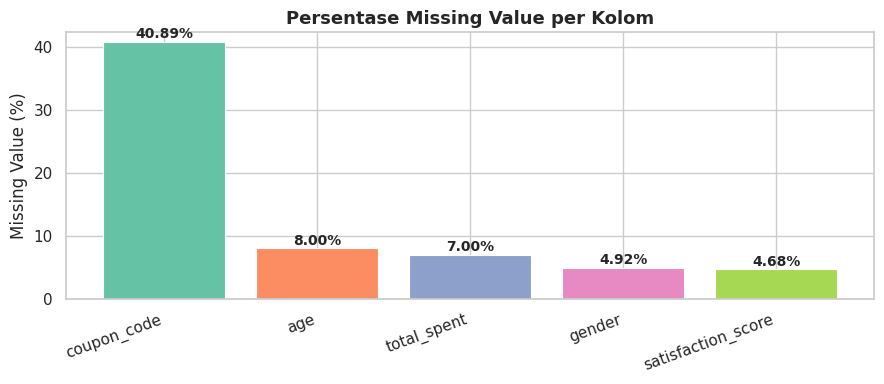

Disimpan: plots/plot_missing_value.png


In [6]:
miss_pct  = (df.isnull().sum() / len(df) * 100).sort_values(ascending=False)
miss_show = miss_pct[miss_pct > 0].reset_index()
miss_show.columns = ['Kolom', 'Missing (%)']
miss_show['Jumlah'] = df.isnull().sum()[miss_show['Kolom']].values

print("Kolom dengan Missing Value:")
display(miss_show)

# Visualisasi
fig, ax = plt.subplots(figsize=(9, 4))
if len(miss_show) > 0:
    palette = sns.color_palette('Set2', len(miss_show))
    bars = ax.bar(miss_show['Kolom'], miss_show['Missing (%)'],
                  color=palette, edgecolor='white', linewidth=0.8)
    for b, v in zip(bars, miss_show['Missing (%)']):
        ax.text(b.get_x() + b.get_width()/2, b.get_height() + 0.05,
                f'{v:.2f}%', ha='center', va='bottom', fontsize=10, fontweight='bold')
    ax.set_title('Persentase Missing Value per Kolom', fontweight='bold', fontsize=13)
    ax.set_ylabel('Missing Value (%)')
    ax.set_ylim(0, miss_show['Missing (%)'].max() + 1.5)
    plt.xticks(rotation=20, ha='right')
else:
    ax.text(0.5, 0.5, 'Tidak ada missing value!',
            ha='center', va='center', transform=ax.transAxes, fontsize=14)
plt.tight_layout()
plt.savefig('../plots/plot_missing_value.png', bbox_inches='tight')
plt.show()
print("Disimpan: plots/plot_missing_value.png")


### 1.6 Distribusi Variabel Target (Churn)

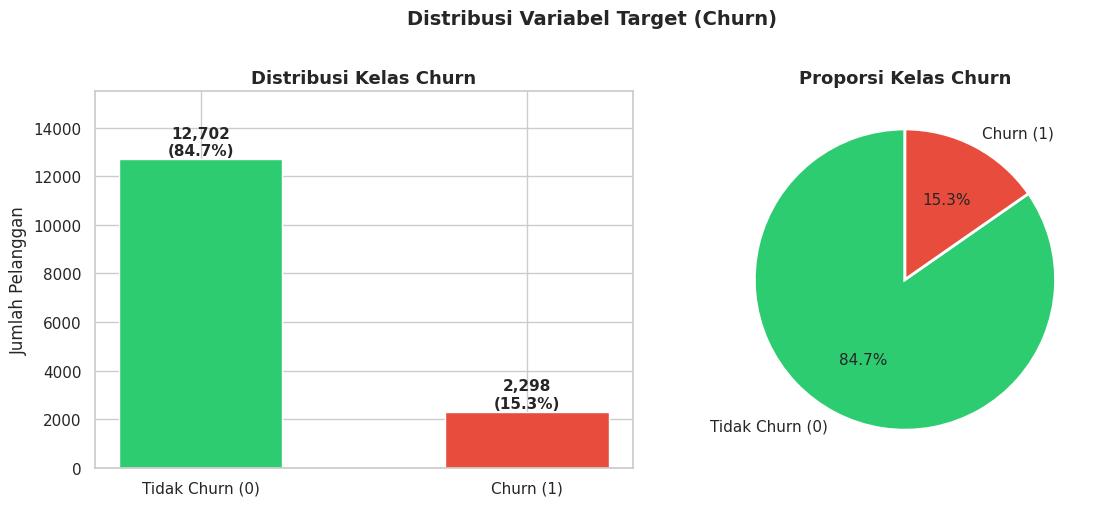

Tidak Churn (0) : 12,702 pelanggan (84.7%)
Churn (1)       : 2,298 pelanggan (15.3%)
Rasio kelas     : 5.53:1


In [7]:
churn_cnt = df['churn'].value_counts().sort_index()
labels    = ['Tidak Churn (0)', 'Churn (1)']
pcts      = (churn_cnt / len(df) * 100).values
colors_c  = ['#2ecc71', '#e74c3c']

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Bar chart
bars = axes[0].bar(labels, churn_cnt.values, color=colors_c, edgecolor='white', width=0.5)
for b, v, p in zip(bars, churn_cnt.values, pcts):
    axes[0].text(b.get_x() + b.get_width()/2, b.get_height() + 50,
                 f'{v:,}\n({p:.1f}%)', ha='center', va='bottom',
                 fontsize=11, fontweight='bold')
axes[0].set_title('Distribusi Kelas Churn', fontweight='bold', fontsize=13)
axes[0].set_ylabel('Jumlah Pelanggan')
axes[0].set_ylim(0, churn_cnt.max() * 1.22)

# Pie chart
axes[1].pie(churn_cnt.values, labels=labels, autopct='%1.1f%%',
            colors=colors_c, startangle=90,
            wedgeprops={'linewidth': 2, 'edgecolor': 'white'},
            textprops={'fontsize': 11})
axes[1].set_title('Proporsi Kelas Churn', fontweight='bold', fontsize=13)

plt.suptitle('Distribusi Variabel Target (Churn)', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('../plots/plot_churn_distribution.png', bbox_inches='tight')
plt.show()

print(f"Tidak Churn (0) : {churn_cnt[0]:,} pelanggan ({pcts[0]:.1f}%)")
print(f"Churn (1)       : {churn_cnt[1]:,} pelanggan ({pcts[1]:.1f}%)")
print(f"Rasio kelas     : {churn_cnt[0]/churn_cnt[1]:.2f}:1")


Distribusi SEBELUM balancing:
  Tidak Churn (0) : 12,702 (84.7%)
  Churn (1)       : 2,298 (15.3%)
  Rasio           : 5.53:1

Distribusi SESUDAH balancing (SMOTE + Undersampling):
  Tidak Churn (0) : 8,891 (50.0%)
  Churn (1)       : 8,891 (50.0%)
  Total sampel    : 17,782 (sebelumnya: 15,000)


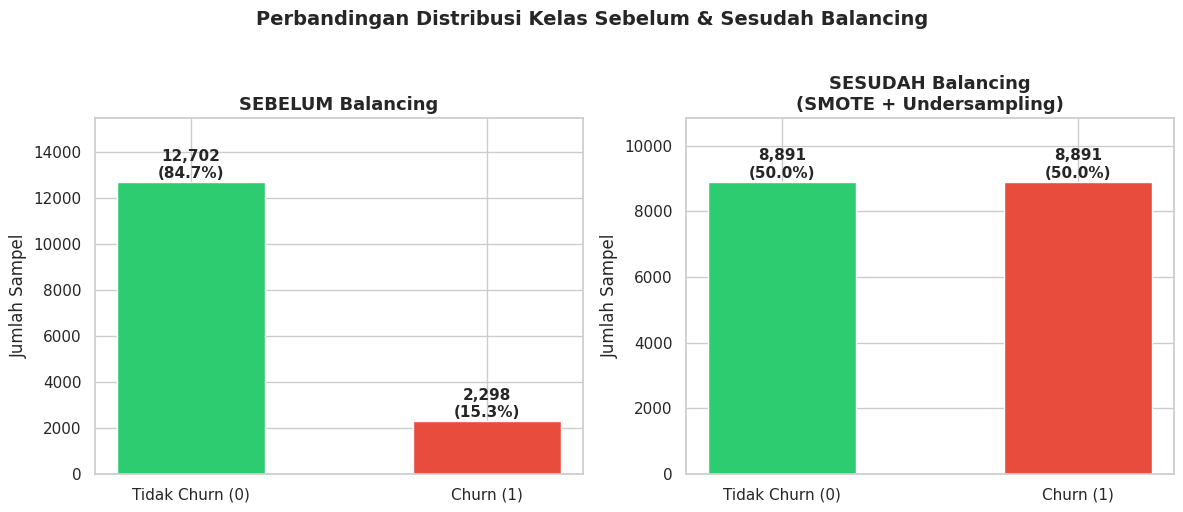

Disimpan: plot_class_balancing.png


In [8]:
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from imblearn.pipeline import Pipeline as ImbPipeline
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Siapkan data untuk balancing
df_bal = df.copy()

# Drop kolom tidak relevan
drop_bal = ['customer_id', 'signup_date', 'last_purchase_date', 'coupon_code']
df_bal.drop(columns=[c for c in drop_bal if c in df_bal.columns], inplace=True)

# Imputasi missing value
for c in df_bal.select_dtypes(include=np.number).columns:
    df_bal[c] = df_bal[c].fillna(df_bal[c].median())
for c in df_bal.select_dtypes(include='object').columns:
    df_bal[c] = df_bal[c].fillna(df_bal[c].mode()[0])

# Label encode kolom object
for col in df_bal.select_dtypes(include='object').columns:
    df_bal[col] = LabelEncoder().fit_transform(df_bal[col].astype(str))

X_bal = df_bal.drop(columns=['churn'])
y_bal = df_bal['churn']

print(f"Distribusi SEBELUM balancing:")
print(f"  Tidak Churn (0) : {(y_bal==0).sum():,} ({(y_bal==0).mean()*100:.1f}%)")
print(f"  Churn (1)       : {(y_bal==1).sum():,} ({(y_bal==1).mean()*100:.1f}%)")
print(f"  Rasio           : {(y_bal==0).sum()/(y_bal==1).sum():.2f}:1")

# Kombinasi SMOTE (oversample minority) + RandomUnderSampler
# SMOTE: minority class dinaikkan ke 70% dari majority
# UnderSampler: majority class diturunkan agar rasio 1:1
balance_pipeline = ImbPipeline(steps=[
    ('smote',  SMOTE(sampling_strategy=0.7, random_state=42)),
    ('under',  RandomUnderSampler(sampling_strategy=1.0, random_state=42))
])

X_balanced, y_balanced = balance_pipeline.fit_resample(X_bal, y_bal)

print(f"\nDistribusi SESUDAH balancing (SMOTE + Undersampling):")
print(f"  Tidak Churn (0) : {(y_balanced==0).sum():,} ({(y_balanced==0).mean()*100:.1f}%)")
print(f"  Churn (1)       : {(y_balanced==1).sum():,} ({(y_balanced==1).mean()*100:.1f}%)")
print(f"  Total sampel    : {len(y_balanced):,} (sebelumnya: {len(y_bal):,})")

# Visualisasi perbandingan sebelum vs sesudah
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
colors = ['#2ecc71', '#e74c3c']
labels = ['Tidak Churn (0)', 'Churn (1)']

# Sebelum
cnt_before = [( y_bal==0).sum(), (y_bal==1).sum()]
bars0 = axes[0].bar(labels, cnt_before, color=colors, edgecolor='white', width=0.5)
for b, v in zip(bars0, cnt_before):
    axes[0].text(b.get_x()+b.get_width()/2, b.get_height()+50,
                 f'{v:,}\n({v/sum(cnt_before)*100:.1f}%)',
                 ha='center', va='bottom', fontsize=11, fontweight='bold')
axes[0].set_title('SEBELUM Balancing', fontweight='bold', fontsize=13)
axes[0].set_ylabel('Jumlah Sampel')
axes[0].set_ylim(0, max(cnt_before)*1.22)

# Sesudah
cnt_after = [(y_balanced==0).sum(), (y_balanced==1).sum()]
bars1 = axes[1].bar(labels, cnt_after, color=colors, edgecolor='white', width=0.5)
for b, v in zip(bars1, cnt_after):
    axes[1].text(b.get_x()+b.get_width()/2, b.get_height()+50,
                 f'{v:,}\n({v/sum(cnt_after)*100:.1f}%)',
                 ha='center', va='bottom', fontsize=11, fontweight='bold')
axes[1].set_title('SESUDAH Balancing\n(SMOTE + Undersampling)', fontweight='bold', fontsize=13)
axes[1].set_ylabel('Jumlah Sampel')
axes[1].set_ylim(0, max(cnt_after)*1.22)

plt.suptitle('Perbandingan Distribusi Kelas Sebelum & Sesudah Balancing',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('plot_class_balancing.png', bbox_inches='tight')
plt.show()
print('Disimpan: plot_class_balancing.png')


 Ringkasan Deteksi Outlier (Metode IQR):


,Q1,Q3,IQR,Batas Bawah,Batas Atas,Jumlah Outlier,Persen (%)
Fitur,,,,,,,
age,28.000000,42.000000,14.000000,7.000000,63.000000,89,0.59%
avg_session_time,5.970000,10.060000,4.090000,-0.150000,16.190000,45,0.30%
total_spent,300.430000,702.400000,401.960000,-302.510000,1305.340000,78,0.52%
avg_order_value,43.030000,76.890000,33.860000,-7.750000,127.670000,54,0.36%
lifetime_value,741.300000,1677.860000,936.560000,-663.540000,3082.700000,56,0.37%
marketing_spend_per_user,11.380000,23.770000,12.390000,-7.200000,42.360000,0,0.00%
total_visits,12.000000,18.000000,6.000000,3.000000,27.000000,39,0.26%
satisfaction_score,3.000000,4.000000,1.000000,1.500000,5.500000,753,5.02%
nps_score,2.000000,8.000000,6.000000,-7.000000,17.000000,0,0.00%


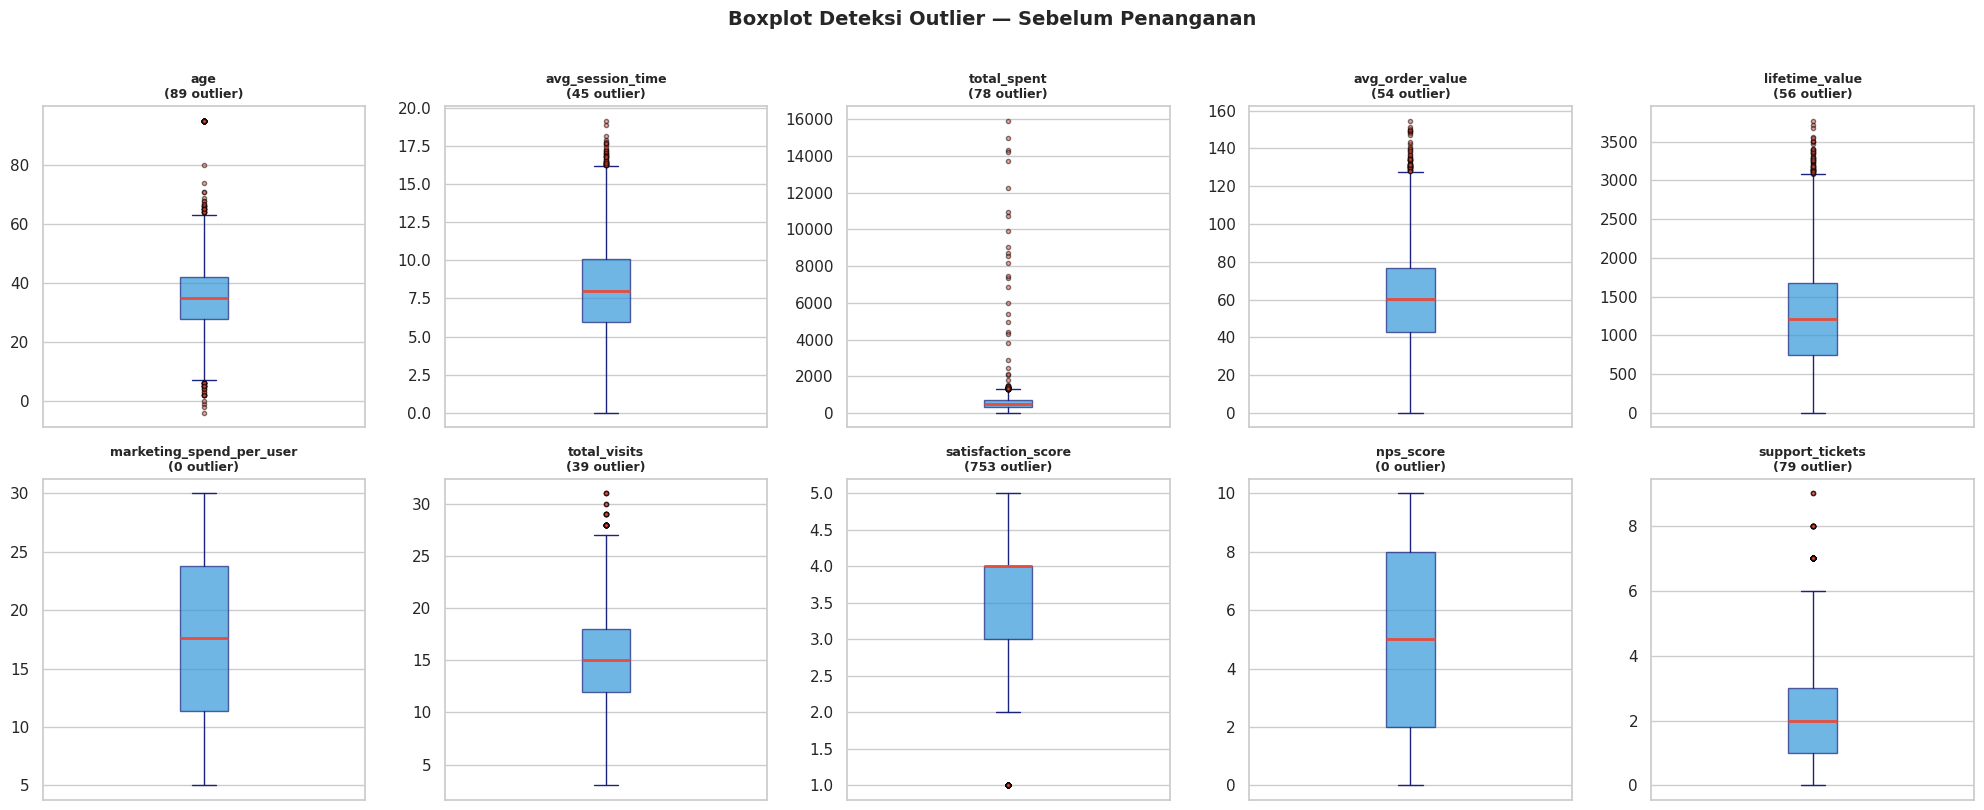

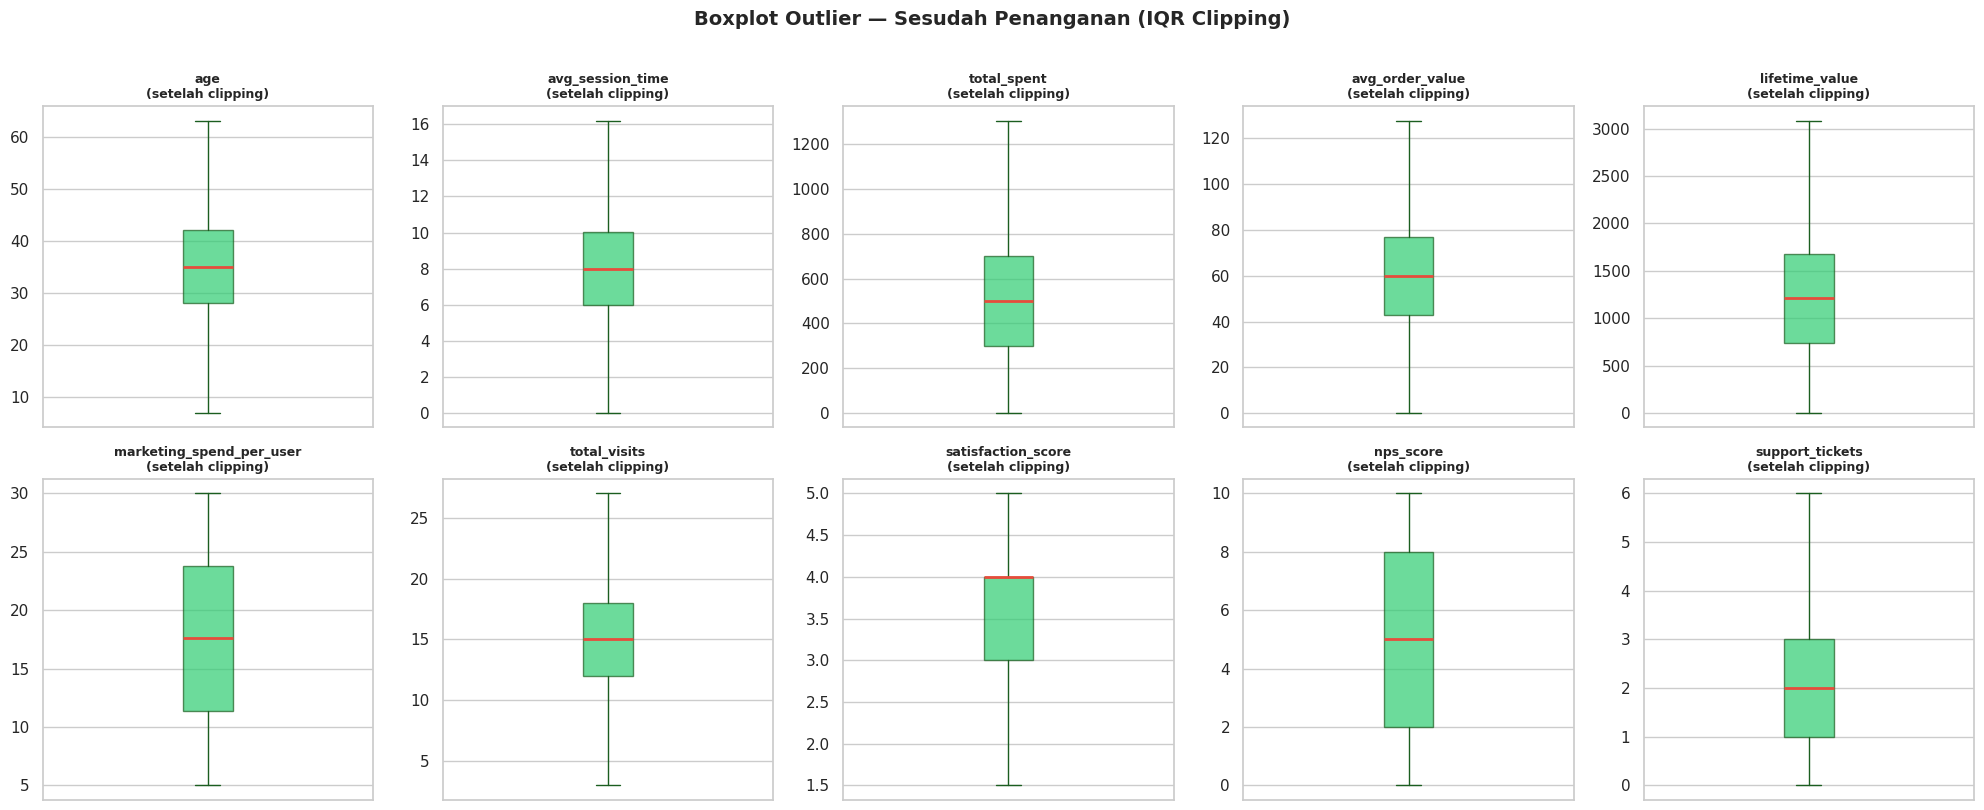

 Disimpan: plot_outlier_before.png & plot_outlier_after.png


In [9]:
# Deteksi outlier menggunakan metode IQR
outlier_cols = ['age', 'avg_session_time', 'total_spent', 'avg_order_value',
                'lifetime_value', 'marketing_spend_per_user', 'total_visits',
                'satisfaction_score', 'nps_score', 'support_tickets']

# Tabel ringkasan outlier
outlier_summary = []
for c in outlier_cols:
    Q1, Q3 = df[c].quantile(0.25), df[c].quantile(0.75)
    IQR = Q3 - Q1
    lo, hi = Q1 - 1.5*IQR, Q3 + 1.5*IQR
    n_out = ((df[c] < lo) | (df[c] > hi)).sum()
    outlier_summary.append({
        'Fitur': c, 'Q1': round(Q1,2), 'Q3': round(Q3,2), 'IQR': round(IQR,2),
        'Batas Bawah': round(lo,2), 'Batas Atas': round(hi,2),
        'Jumlah Outlier': n_out,
        'Persen (%)': round(n_out/len(df)*100, 2)
    })

df_outlier = pd.DataFrame(outlier_summary)
print(' Ringkasan Deteksi Outlier (Metode IQR):')
display(df_outlier.set_index('Fitur').style
        .background_gradient(cmap='Reds', subset=['Jumlah Outlier', 'Persen (%)'])
        .format({'Persen (%)': '{:.2f}%'}))

# Boxplot sebelum penanganan outlier
fig, axes = plt.subplots(2, 5, figsize=(20, 8))
axes = axes.flatten()

for ax, col in zip(axes, outlier_cols):
    Q1, Q3 = df[col].quantile(0.25), df[col].quantile(0.75)
    IQR = Q3 - Q1
    lo, hi = Q1 - 1.5*IQR, Q3 + 1.5*IQR
    n_out = ((df[col] < lo) | (df[col] > hi)).sum()

    ax.boxplot(df[col].dropna(), patch_artist=True,
               boxprops=dict(facecolor='#3498db', color='#1a237e', alpha=0.7),
               medianprops=dict(color='#e74c3c', linewidth=2),
               whiskerprops=dict(color='#1a237e'),
               capprops=dict(color='#1a237e'),
               flierprops=dict(marker='o', markerfacecolor='#e74c3c',
                               markersize=3, alpha=0.5, linestyle='none'))
    ax.set_title(f'{col}\n({n_out} outlier)', fontsize=9, fontweight='bold')
    ax.set_xticks([])

plt.suptitle('Boxplot Deteksi Outlier — Sebelum Penanganan',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('plot_outlier_before.png', bbox_inches='tight')
plt.show()

# Boxplot sesudah IQR clipping
df_clipped = df[outlier_cols].copy()
for c in outlier_cols:
    Q1, Q3 = df_clipped[c].quantile(0.25), df_clipped[c].quantile(0.75)
    IQR = Q3 - Q1
    df_clipped[c] = df_clipped[c].clip(Q1 - 1.5*IQR, Q3 + 1.5*IQR)

fig, axes = plt.subplots(2, 5, figsize=(20, 8))
axes = axes.flatten()

for ax, col in zip(axes, outlier_cols):
    ax.boxplot(df_clipped[col].dropna(), patch_artist=True,
               boxprops=dict(facecolor='#2ecc71', color='#1b5e20', alpha=0.7),
               medianprops=dict(color='#e74c3c', linewidth=2),
               whiskerprops=dict(color='#1b5e20'),
               capprops=dict(color='#1b5e20'),
               flierprops=dict(marker='o', markerfacecolor='#e74c3c',
                               markersize=3, alpha=0.5, linestyle='none'))
    ax.set_title(f'{col}\n(setelah clipping)', fontsize=9, fontweight='bold')
    ax.set_xticks([])

plt.suptitle('Boxplot Outlier — Sesudah Penanganan (IQR Clipping)',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('plot_outlier_after.png', bbox_inches='tight')
plt.show()
print(' Disimpan: plot_outlier_before.png & plot_outlier_after.png')


### 1.7 Heatmap Korelasi Fitur Numerik

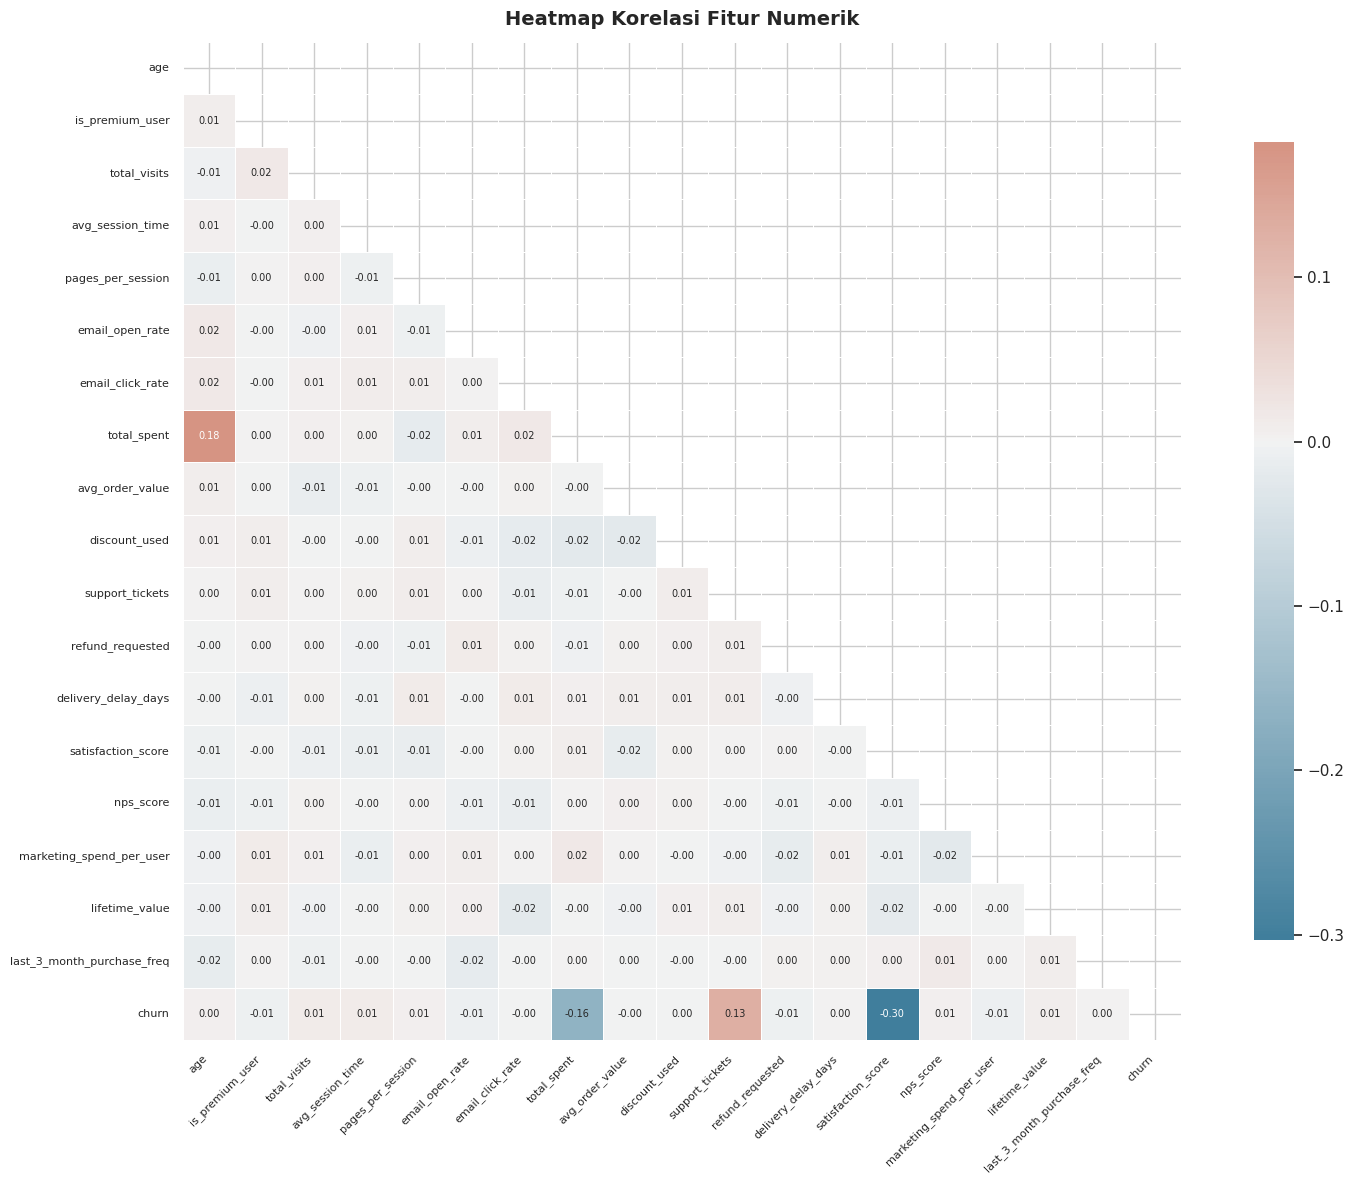

Disimpan: plots/plot_heatmap_korelasi.png


In [10]:
num_cols = [c for c in df.select_dtypes(include=np.number).columns if c != 'customer_id']
corr     = df[num_cols].corr()

fig, ax = plt.subplots(figsize=(16, 12))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f',
            cmap=sns.diverging_palette(230, 20, as_cmap=True), center=0,
            linewidths=0.5, linecolor='white', square=True, ax=ax,
            annot_kws={'size': 7}, cbar_kws={'shrink': 0.8})
ax.set_title('Heatmap Korelasi Fitur Numerik', fontsize=14, fontweight='bold', pad=12)
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.yticks(fontsize=8)
plt.tight_layout()
plt.savefig('../plots/plot_heatmap_korelasi.png', bbox_inches='tight')
plt.show()
print("Disimpan: plots/plot_heatmap_korelasi.png")


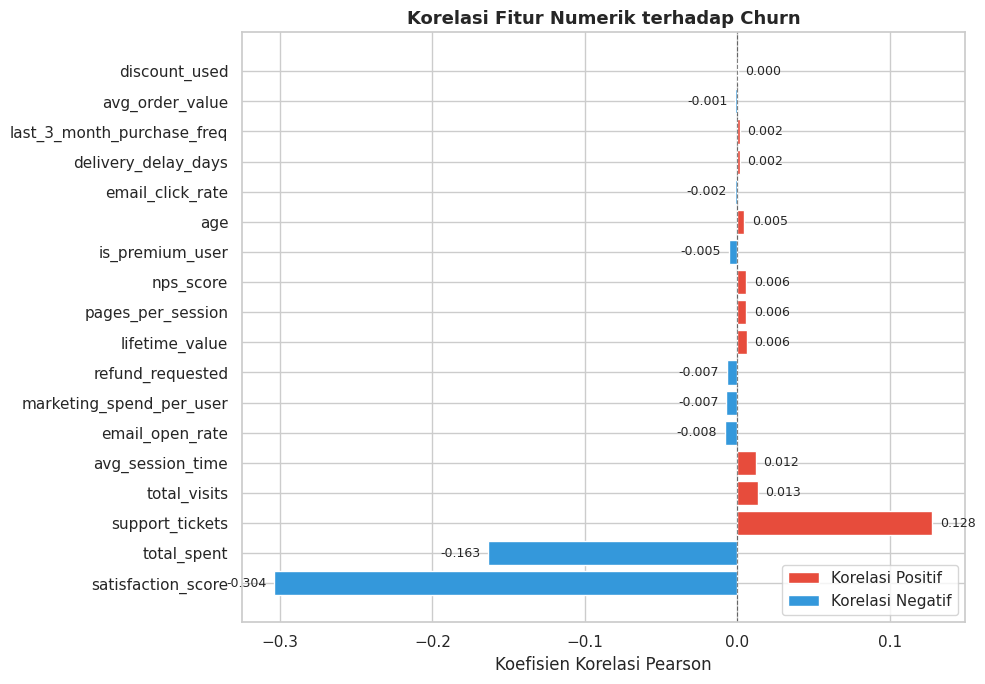

Top 5 Korelasi Positif dengan Churn:
support_tickets     0.1279
total_visits        0.0132
avg_session_time    0.0122
lifetime_value      0.0063
pages_per_session   0.0059
Top 5 Korelasi Negatif dengan Churn:
satisfaction_score         -0.3036
total_spent                -0.1633
email_open_rate            -0.0084
marketing_spend_per_user   -0.0073
refund_requested           -0.0070


In [11]:
# Korelasi fitur terhadap variabel target 'churn'
churn_corr = corr['churn'].drop('churn').sort_values(key=abs, ascending=False)

fig, ax = plt.subplots(figsize=(10, 7))
bar_colors = ['#e74c3c' if v > 0 else '#3498db' for v in churn_corr.values]
bars = ax.barh(churn_corr.index, churn_corr.values, color=bar_colors, edgecolor='white')
for b, v in zip(bars, churn_corr.values):
    xp = v + 0.005 if v >= 0 else v - 0.005
    ax.text(xp, b.get_y() + b.get_height()/2, f'{v:.3f}',
            va='center', ha='left' if v >= 0 else 'right', fontsize=9)
ax.axvline(0, color='black', lw=0.8, ls='--', alpha=0.5)
ax.set_title('Korelasi Fitur Numerik terhadap Churn', fontweight='bold', fontsize=13)
ax.set_xlabel('Koefisien Korelasi Pearson')
from matplotlib.patches import Patch
ax.legend(handles=[Patch(facecolor='#e74c3c', label='Korelasi Positif'),
                   Patch(facecolor='#3498db', label='Korelasi Negatif')], loc='lower right')
plt.tight_layout()
plt.savefig('../plots/plot_korelasi_churn.png', bbox_inches='tight')
plt.show()

print("Top 5 Korelasi Positif dengan Churn:")
print(churn_corr[churn_corr > 0].head(5).to_string())
print("Top 5 Korelasi Negatif dengan Churn:")
print(churn_corr[churn_corr < 0].head(5).to_string())


### 1.8 Distribusi Fitur Numerik Utama per Kelas Churn

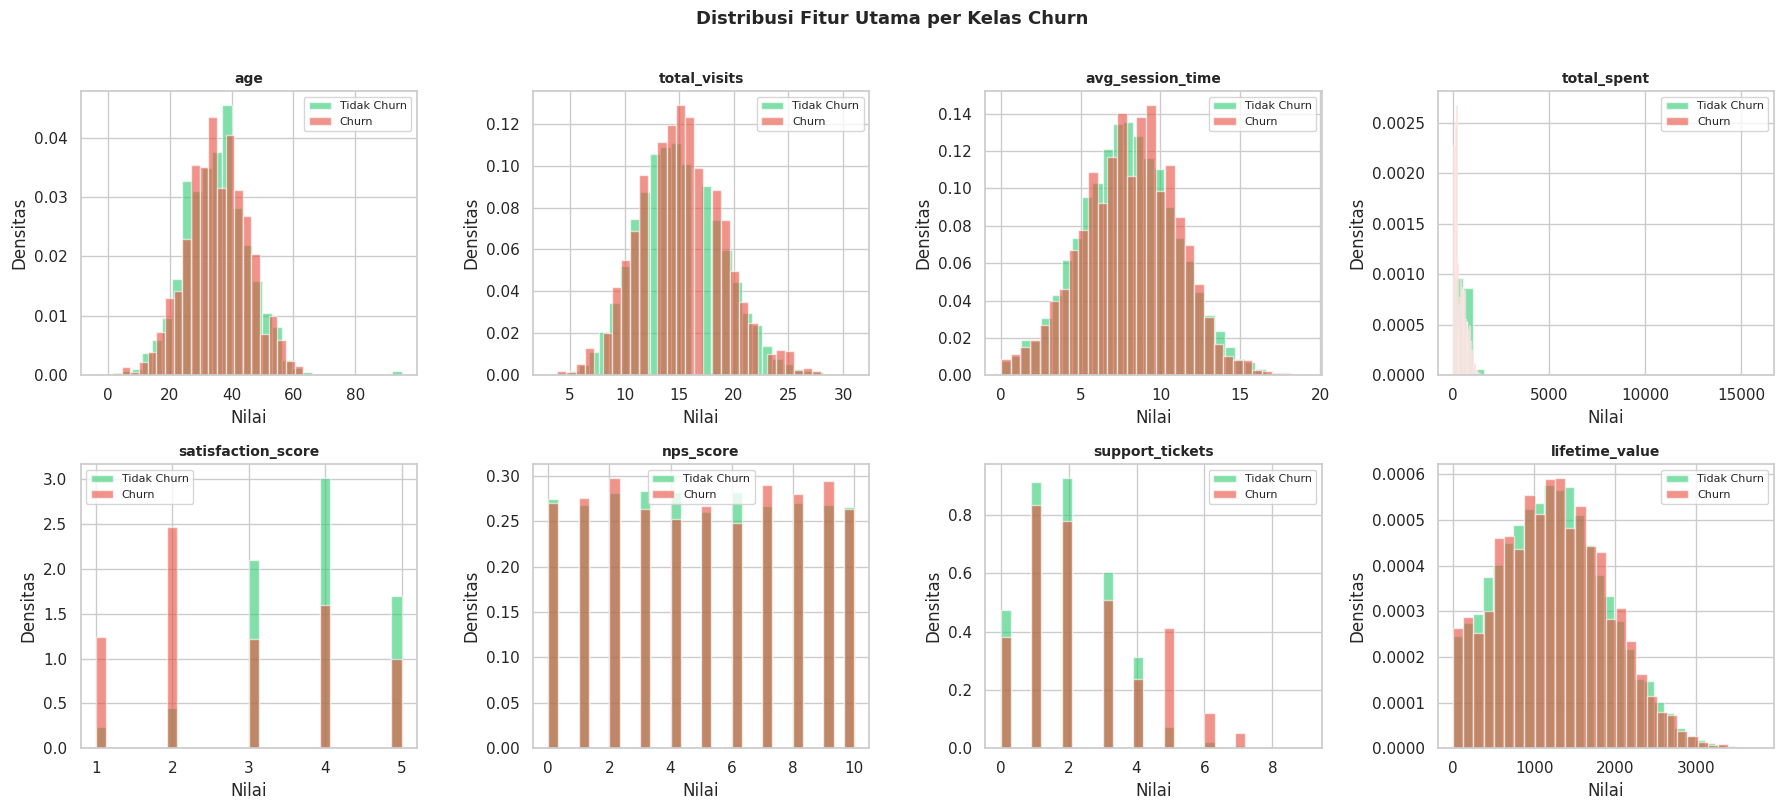

Disimpan: plots/plot_distribusi_fitur.png


In [12]:
top8 = ['age', 'total_visits', 'avg_session_time', 'total_spent',
        'satisfaction_score', 'nps_score', 'support_tickets', 'lifetime_value']

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()
for ax, col in zip(axes, top8):
    d0 = df[df['churn'] == 0][col].dropna()
    d1 = df[df['churn'] == 1][col].dropna()
    ax.hist(d0, bins=30, alpha=0.6, color='#2ecc71', label='Tidak Churn', density=True)
    ax.hist(d1, bins=30, alpha=0.6, color='#e74c3c', label='Churn', density=True)
    ax.set_title(col, fontweight='bold', fontsize=10)
    ax.set_xlabel('Nilai'); ax.set_ylabel('Densitas')
    ax.legend(fontsize=8)
plt.suptitle('Distribusi Fitur Utama per Kelas Churn', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('../plots/plot_distribusi_fitur.png', bbox_inches='tight')
plt.show()
print("Disimpan: plots/plot_distribusi_fitur.png")


### 1.9 Analisis Fitur Kategorikal vs Churn

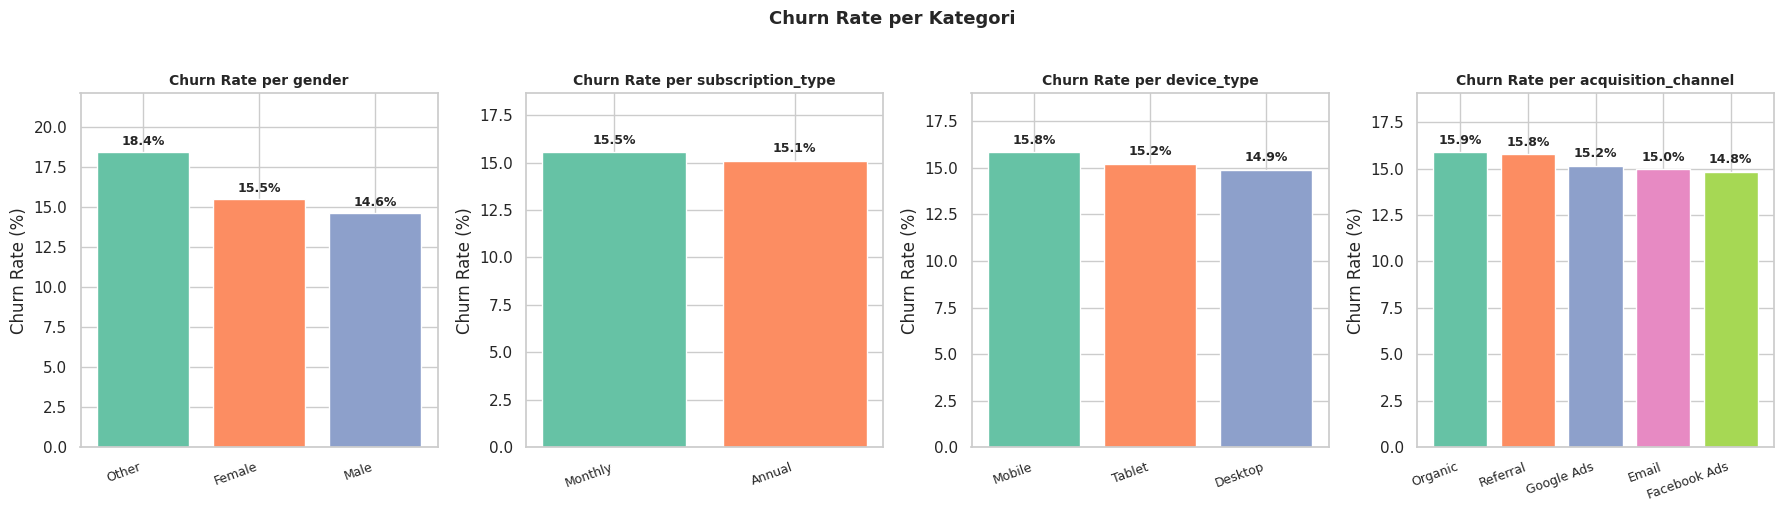

In [13]:
cat_analyze = ['gender', 'subscription_type', 'device_type', 'acquisition_channel']
fig, axes   = plt.subplots(1, 4, figsize=(18, 5))

for ax, col in zip(axes, cat_analyze):
    churn_rate = df.groupby(col)['churn'].mean().sort_values(ascending=False)
    bars = ax.bar(churn_rate.index, churn_rate.values * 100,
                  color=sns.color_palette('Set2', len(churn_rate)), edgecolor='white')
    for b, v in zip(bars, churn_rate.values * 100):
        ax.text(b.get_x() + b.get_width()/2, b.get_height() + 0.3,
                f'{v:.1f}%', ha='center', va='bottom', fontsize=9, fontweight='bold')
    ax.set_title(f'Churn Rate per {col}', fontweight='bold', fontsize=10)
    ax.set_ylabel('Churn Rate (%)')
    ax.set_ylim(0, churn_rate.max() * 120)
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=20, ha='right', fontsize=9)

plt.suptitle('Churn Rate per Kategori', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../plots/plot_churn_rate_kategori.png', bbox_inches='tight')
plt.show()


---
##  Bagian 2 — Direct Modeling (Tanpa Preprocessing)

 Model dilatih **langsung** tanpa preprocessing mendalam dan tanpa hyperparameter tuning.

 Hanya dilakukan encoding minimal dan imputasi sederhana agar model bisa berjalan.

---


### 2.1 Persiapan Data (Minimal)

In [14]:
 # Load ulang data segar
df_dir = pd.read_csv('/content/Sales - Marketing customer dataset.csv')

# Drop kolom identifier & tanggal
drop_dir = ['customer_id', 'signup_date', 'last_purchase_date', 'coupon_code']
df_dir.drop(columns=drop_dir, inplace=True)

# Imputasi MINIMAL (hanya agar tidak error, bukan preprocessing penuh)
for c in df_dir.select_dtypes(include=np.number).columns:
    df_dir[c] = df_dir[c].fillna(df_dir[c].median())
for c in df_dir.select_dtypes(include='object').columns:
    df_dir[c] = df_dir[c].fillna(df_dir[c].mode()[0])

# Label Encoding minimal
for col in df_dir.select_dtypes(include='object').columns:
    df_dir[col] = LabelEncoder().fit_transform(df_dir[col].astype(str))

# Fitur dan target
X_dir = df_dir.drop(columns=['churn'])
y_dir = df_dir['churn']

# Train-test split 80:20
X_tr_d, X_te_d, y_tr_d, y_te_d = train_test_split(
    X_dir, y_dir, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y_dir)

print(f"Fitur (X): {X_dir.shape[1]} kolom")
print(f"   Data latih : {X_tr_d.shape[0]:,} sampel ({(1-TEST_SIZE)*100:.0f}%)")
print(f"   Data uji   : {X_te_d.shape[0]:,} sampel ({TEST_SIZE*100:.0f}%)")
print(f"Distribusi kelas — data latih: {dict(y_tr_d.value_counts().sort_index())}")
print(f"Distribusi kelas — data uji  : {dict(y_te_d.value_counts().sort_index())}")


Fitur (X): 25 kolom
   Data latih : 12,000 sampel (80%)
   Data uji   : 3,000 sampel (20%)
Distribusi kelas — data latih: {0: np.int64(10162), 1: np.int64(1838)}
Distribusi kelas — data uji  : {0: np.int64(2540), 1: np.int64(460)}


### 2.2 Fungsi Evaluasi

In [15]:
def eval_model(name, model, Xtr, Xte, ytr, yte):
    """Latih model dan cetak semua metrik evaluasi."""
    model.fit(Xtr, ytr)
    yp   = model.predict(Xte)
    acc  = accuracy_score(yte, yp)
    prec = precision_score(yte, yp, zero_division=0)
    rec  = recall_score(yte, yp, zero_division=0)
    f1   = f1_score(yte, yp, zero_division=0)
    cm   = confusion_matrix(yte, yp)
    label = name.replace('\n', ' ')
    print(f"\n{'='*58}")
    print(f"  {label}")
    print(f"{'='*58}")
    print(f"  Accuracy  : {acc:.4f}  ({acc*100:.2f}%)")
    print(f"  Precision : {prec:.4f}")
    print(f"  Recall    : {rec:.4f}")
    print(f"  F1-Score  : {f1:.4f}")
    print(f"\n  Classification Report:")
    print(classification_report(yte, yp,
          target_names=['Tidak Churn (0)', 'Churn (1)'], zero_division=0))
    return {'Model': name, 'Accuracy': acc, 'Precision': prec,
            'Recall': rec, 'F1-Score': f1, 'CM': cm, 'obj': model}

print("Fungsi eval_model siap digunakan")


Fungsi eval_model siap digunakan


### 2.3 Definisi & Pelatihan Tiga Model

In [16]:
models_dir = {
    'Logistic Regression\n(Konvensional)':
        LogisticRegression(max_iter=300, random_state=RANDOM_STATE),

    'Random Forest\n(Ensemble Bagging)':
        RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE, n_jobs=-1),

    'Voting Classifier\n(LR + SVM + KNN)':
        VotingClassifier(
            estimators=[
                ('lr',  LogisticRegression(max_iter=300, random_state=RANDOM_STATE)),
                ('svm', SVC(probability=True, random_state=RANDOM_STATE)),
                ('knn', KNeighborsClassifier(n_neighbors=5))
            ], voting='soft')
}

print("Melatih tiga model direct...")
results_dir = []
for name, mdl in models_dir.items():
    res = eval_model(name, mdl, X_tr_d, X_te_d, y_tr_d, y_te_d)
    results_dir.append(res)


Melatih tiga model direct...

  Logistic Regression (Konvensional)
  Accuracy  : 0.8467  (84.67%)
  Precision : 0.5000
  Recall    : 0.1500
  F1-Score  : 0.2308

  Classification Report:
                 precision    recall  f1-score   support

Tidak Churn (0)       0.86      0.97      0.91      2540
      Churn (1)       0.50      0.15      0.23       460

       accuracy                           0.85      3000
      macro avg       0.68      0.56      0.57      3000
   weighted avg       0.81      0.85      0.81      3000


  Random Forest (Ensemble Bagging)
  Accuracy  : 0.8477  (84.77%)
  Precision : 0.5046
  Recall    : 0.3565
  F1-Score  : 0.4178

  Classification Report:
                 precision    recall  f1-score   support

Tidak Churn (0)       0.89      0.94      0.91      2540
      Churn (1)       0.50      0.36      0.42       460

       accuracy                           0.85      3000
      macro avg       0.70      0.65      0.67      3000
   weighted avg       0.8

### 2.4 Visualisasi Confusion Matrix

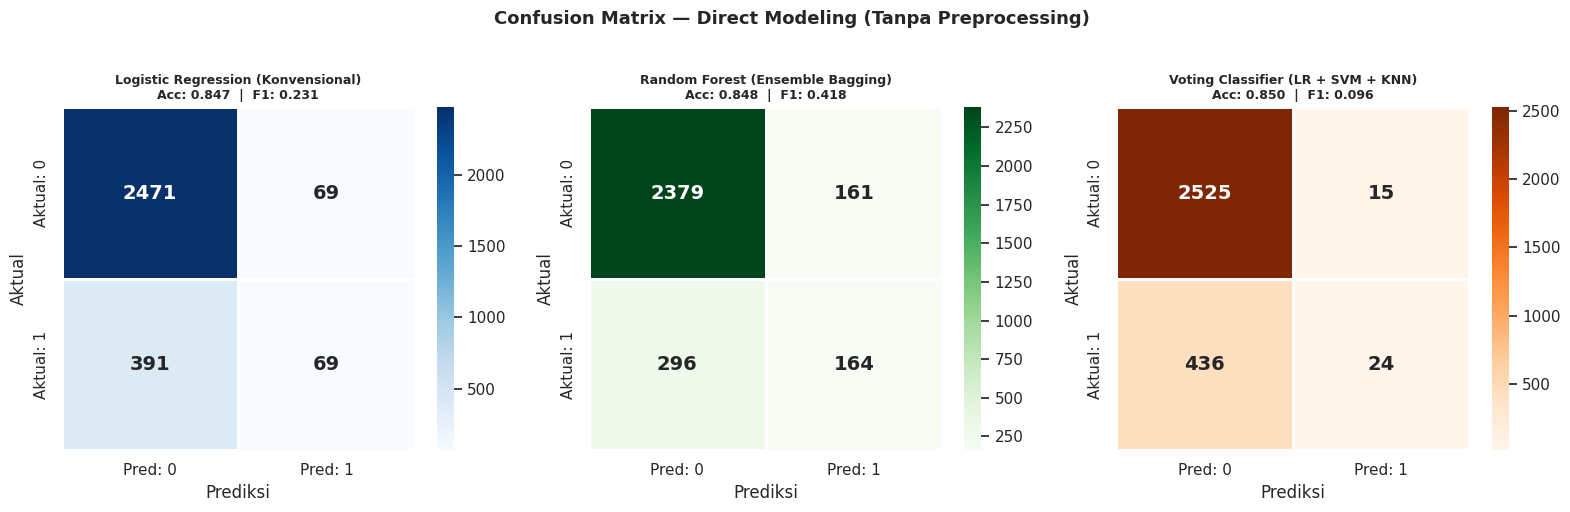

Disimpan: plots/plot_cm_direct.png


In [17]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
cmaps_ = ['Blues', 'Greens', 'Oranges']

for ax, res, cmap_ in zip(axes, results_dir, cmaps_):
    sn = res['Model'].replace('\n', ' ')
    sns.heatmap(res['CM'], annot=True, fmt='d', cmap=cmap_, ax=ax,
                xticklabels=['Pred: 0', 'Pred: 1'],
                yticklabels=['Aktual: 0', 'Aktual: 1'],
                linewidths=1, linecolor='white',
                annot_kws={'size': 14, 'weight': 'bold'})
    ax.set_title(f"{sn}\nAcc: {res['Accuracy']:.3f}  |  F1: {res['F1-Score']:.3f}",
                 fontsize=9, fontweight='bold')
    ax.set_xlabel('Prediksi'); ax.set_ylabel('Aktual')

plt.suptitle('Confusion Matrix — Direct Modeling (Tanpa Preprocessing)',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../plots/plot_cm_direct.png', bbox_inches='tight')
plt.show()
print("Disimpan: plots/plot_cm_direct.png")


### 2.5 Ringkasan Metrik Direct Modeling

Tabel Ringkasan — Direct Modeling:


,Accuracy,Precision,Recall,F1-Score
Model,,,,
Logistic Regression (Konvensional),0.8467,0.5000,0.1500,0.2308
Random Forest (Ensemble Bagging),0.8477,0.5046,0.3565,0.4178
Voting Classifier (LR + SVM + KNN),0.8497,0.6154,0.0522,0.0962


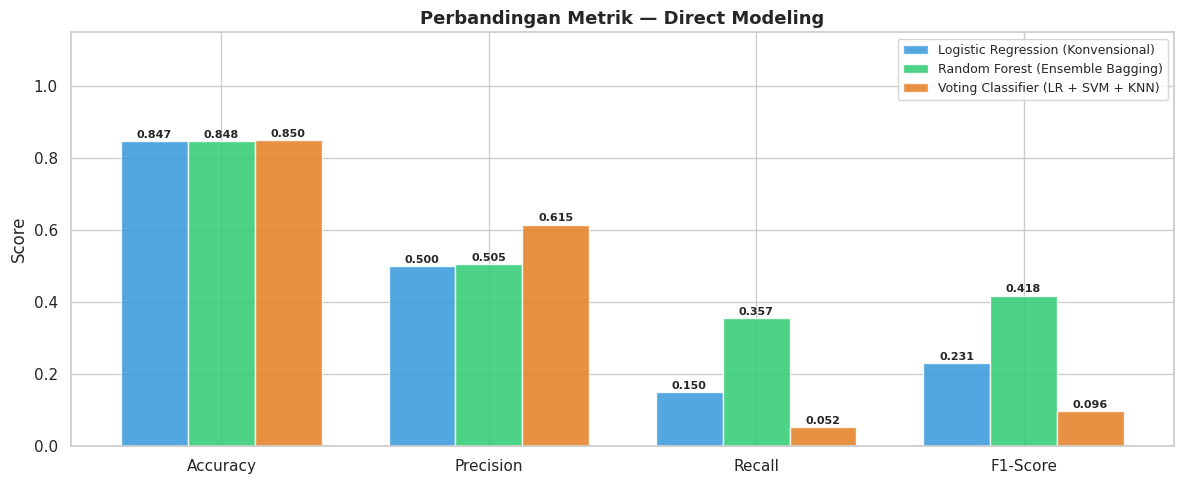

In [18]:
metrics_keys = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
summ_d = pd.DataFrame([{k: r[k] for k in ['Model'] + metrics_keys} for r in results_dir])
summ_d['Model'] = summ_d['Model'].str.replace('\n', ' ')

print("Tabel Ringkasan — Direct Modeling:")
display(summ_d.set_index('Model').style
        .format('{:.4f}')
        .background_gradient(cmap='YlGn', subset=['Accuracy', 'F1-Score'])
        .set_caption('Direct Modeling — Tanpa Preprocessing'))

# Bar chart perbandingan
fig, ax = plt.subplots(figsize=(12, 5))
x = np.arange(len(metrics_keys)); w = 0.25
colors_m = ['#3498db', '#2ecc71', '#e67e22']

for i, (res, col) in enumerate(zip(results_dir, colors_m)):
    vals = [res[k] for k in metrics_keys]
    bars = ax.bar(x + i*w, vals, w, label=res['Model'].replace('\n', ' '),
                  color=col, alpha=0.85, edgecolor='white')
    for b, v in zip(bars, vals):
        ax.text(b.get_x() + b.get_width()/2, b.get_height() + 0.003,
                f'{v:.3f}', ha='center', va='bottom', fontsize=8, fontweight='bold')

ax.set_xticks(x + w); ax.set_xticklabels(metrics_keys, fontsize=11)
ax.set_ylabel('Score'); ax.set_ylim(0, 1.15)
ax.set_title('Perbandingan Metrik — Direct Modeling', fontweight='bold', fontsize=13)
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig('../plots/plot_metrik_direct.png', bbox_inches='tight')
plt.show()


---
##  Bagian 3 — Modeling dengan Preprocessing

> Data dibersihkan secara menyeluruh sebelum pelatihan.
> **Scaling dilakukan SETELAH train-test split** untuk menghindari data leakage.

---


### 3.1 Penanganan Missing Value, Duplikat & Outlier

In [19]:
df_pp = pd.read_csv('/content/Sales - Marketing customer dataset.csv')
print(f"Shape awal  : {df_pp.shape}")
print(f"Duplikat    : {df_pp.duplicated().sum()}")
print(f"Total NaN   : {df_pp.isnull().sum().sum()}")

# 1️ Hapus duplikat
n_before = len(df_pp)
df_pp.drop_duplicates(inplace=True)
print(f"\n[1] Duplikat dihapus: {n_before - len(df_pp)} baris")

# 2️ Drop kolom tidak relevan
drop_irr = ['customer_id', 'signup_date', 'last_purchase_date', 'coupon_code']
df_pp.drop(columns=drop_irr, inplace=True)
print(f"[2] Kolom dihapus   : {drop_irr}")

# 3️ Imputasi missing value (sebelum encoding)
print("\n[3] Imputasi missing value:")
for c in df_pp.select_dtypes(include=np.number).columns:
    n = df_pp[c].isnull().sum()
    if n > 0:
        val = df_pp[c].median()
        df_pp[c] = df_pp[c].fillna(val)
        print(f"    '{c}': {n} nilai → median = {val:.2f}")
for c in df_pp.select_dtypes(include='object').columns:
    n = df_pp[c].isnull().sum()
    if n > 0:
        val = df_pp[c].mode()[0]
        df_pp[c] = df_pp[c].fillna(val)
        print(f"    '{c}': {n} nilai → modus = '{val}'")

assert df_pp.isnull().sum().sum() == 0, " Masih ada NaN!"
print("Tidak ada missing value tersisa")

# 4️ Outlier — IQR clipping
print("\n[4] Penanganan outlier (IQR clipping):")
clip_cols = ['age', 'avg_session_time', 'total_spent', 'avg_order_value',
             'lifetime_value', 'marketing_spend_per_user']
for c in clip_cols:
    Q1, Q3 = df_pp[c].quantile(0.25), df_pp[c].quantile(0.75)
    IQR = Q3 - Q1
    lo, hi = Q1 - 1.5*IQR, Q3 + 1.5*IQR
    n_out = ((df_pp[c] < lo) | (df_pp[c] > hi)).sum()
    df_pp[c] = df_pp[c].clip(lo, hi)
    print(f"    '{c}': {n_out} outlier → clip [{lo:.1f}, {hi:.1f}]")

print(f"Shape setelah preprocessing awal: {df_pp.shape}")

Shape awal  : (15000, 30)
Duplikat    : 0
Total NaN   : 9823

[1] Duplikat dihapus: 0 baris
[2] Kolom dihapus   : ['customer_id', 'signup_date', 'last_purchase_date', 'coupon_code']

[3] Imputasi missing value:
    'age': 1200 nilai → median = 35.00
    'total_spent': 1050 nilai → median = 498.84
    'satisfaction_score': 702 nilai → median = 4.00
    'gender': 738 nilai → modus = 'Male'
Tidak ada missing value tersisa

[4] Penanganan outlier (IQR clipping):
    'age': 218 outlier → clip [11.0, 59.0]
    'avg_session_time': 45 outlier → clip [-0.2, 16.2]
    'total_spent': 119 outlier → clip [-232.5, 1233.6]
    'avg_order_value': 54 outlier → clip [-7.8, 127.7]
    'lifetime_value': 56 outlier → clip [-663.5, 3082.7]
    'marketing_spend_per_user': 0 outlier → clip [-7.2, 42.4]
Shape setelah preprocessing awal: (15000, 26)


### 3.2 Encoding Fitur Kategorikal

In [20]:
cat_cols = df_pp.select_dtypes(include='object').columns.tolist()
print(f"Kolom kategorikal yang akan diencode: {cat_cols}\n")

le_map = {}
for col in cat_cols:
    le = LabelEncoder()
    df_pp[col] = le.fit_transform(df_pp[col].astype(str))
    le_map[col] = le
    print(f"  '{col}': {len(le.classes_)} kelas → {dict(zip(le.classes_[:4], le.transform(le.classes_[:4])))}")

print(f"Encoding selesai. Shape: {df_pp.shape}")
print(f"   NaN setelah encode: {df_pp.isnull().sum().sum()}")


Kolom kategorikal yang akan diencode: ['gender', 'country', 'city', 'acquisition_channel', 'device_type', 'subscription_type', 'payment_method']

  'gender': 3 kelas → {'Female': np.int64(0), 'Male': np.int64(1), 'Other': np.int64(2)}
  'country': 5 kelas → {'Bangladesh': np.int64(0), 'Germany': np.int64(1), 'India': np.int64(2), 'UK': np.int64(3)}
  'city': 7 kelas → {'Berlin': np.int64(0), 'Delhi': np.int64(1), 'Dhaka': np.int64(2), 'Hamburg': np.int64(3)}
  'acquisition_channel': 5 kelas → {'Email': np.int64(0), 'Facebook Ads': np.int64(1), 'Google Ads': np.int64(2), 'Organic': np.int64(3)}
  'device_type': 3 kelas → {'Desktop': np.int64(0), 'Mobile': np.int64(1), 'Tablet': np.int64(2)}
  'subscription_type': 2 kelas → {'Annual': np.int64(0), 'Monthly': np.int64(1)}
  'payment_method': 5 kelas → {'BKash': np.int64(0), 'Card': np.int64(1), 'PayPal': np.int64(2), 'SEPA': np.int64(3)}
Encoding selesai. Shape: (15000, 26)
   NaN setelah encode: 0


### 3.3 Train-Test Split & Feature Scaling

In [21]:
X_pp = df_pp.drop(columns=['churn'])
y_pp = df_pp['churn']

# Split dengan proporsi sama seperti direct modeling (80:20, stratified)
X_tr_p, X_te_p, y_tr_p, y_te_p = train_test_split(
    X_pp, y_pp, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y_pp)

# ─── SCALING dilakukan SETELAH split ─────────────────────────────────────────
# fit_transform hanya pada data LATIH, transform saja pada data UJI
scaler_pp = StandardScaler()
X_tr_p_sc = scaler_pp.fit_transform(X_tr_p)   # fit + transform
X_te_p_sc = scaler_pp.transform(X_te_p)        # transform saja (no leakage)

print(f"Data latih  : {X_tr_p_sc.shape} (scaled)")
print(f"Data uji    : {X_te_p_sc.shape} (scaled)")
print(f" Scaling selesai — StandardScaler di-fit HANYA pada data latih")
print(f"   → Tidak ada data leakage dari data uji")


Data latih  : (12000, 25) (scaled)
Data uji    : (3000, 25) (scaled)
 Scaling selesai — StandardScaler di-fit HANYA pada data latih
   → Tidak ada data leakage dari data uji


### 3.4 Latih Ulang Tiga Model dengan Data Bersih

In [22]:
models_pp = {
    'Logistic Regression\n(Konvensional)':
        LogisticRegression(max_iter=500, random_state=RANDOM_STATE),

    'Random Forest\n(Ensemble Bagging)':
        RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE, n_jobs=-1),

    'Voting Classifier\n(LR + SVM + KNN)':
        VotingClassifier(
            estimators=[
                ('lr',  LogisticRegression(max_iter=500, random_state=RANDOM_STATE)),
                ('svm', SVC(probability=True, random_state=RANDOM_STATE)),
                ('knn', KNeighborsClassifier(n_neighbors=5))
            ], voting='soft')
}

print(" Melatih model dengan data preprocessing...")
results_pp = []
for name, mdl in models_pp.items():
    res = eval_model(name, mdl, X_tr_p_sc, X_te_p_sc, y_tr_p, y_te_p)
    results_pp.append(res)


 Melatih model dengan data preprocessing...

  Logistic Regression (Konvensional)
  Accuracy  : 0.8433  (84.33%)
  Precision : 0.4653
  Recall    : 0.1457
  F1-Score  : 0.2219

  Classification Report:
                 precision    recall  f1-score   support

Tidak Churn (0)       0.86      0.97      0.91      2540
      Churn (1)       0.47      0.15      0.22       460

       accuracy                           0.84      3000
      macro avg       0.66      0.56      0.57      3000
   weighted avg       0.80      0.84      0.81      3000


  Random Forest (Ensemble Bagging)
  Accuracy  : 0.8497  (84.97%)
  Precision : 0.5157
  Recall    : 0.3217
  F1-Score  : 0.3963

  Classification Report:
                 precision    recall  f1-score   support

Tidak Churn (0)       0.88      0.95      0.91      2540
      Churn (1)       0.52      0.32      0.40       460

       accuracy                           0.85      3000
      macro avg       0.70      0.63      0.66      3000
   weighte

In [25]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


### 3.5 Confusion Matrix & Ringkasan Preprocessing

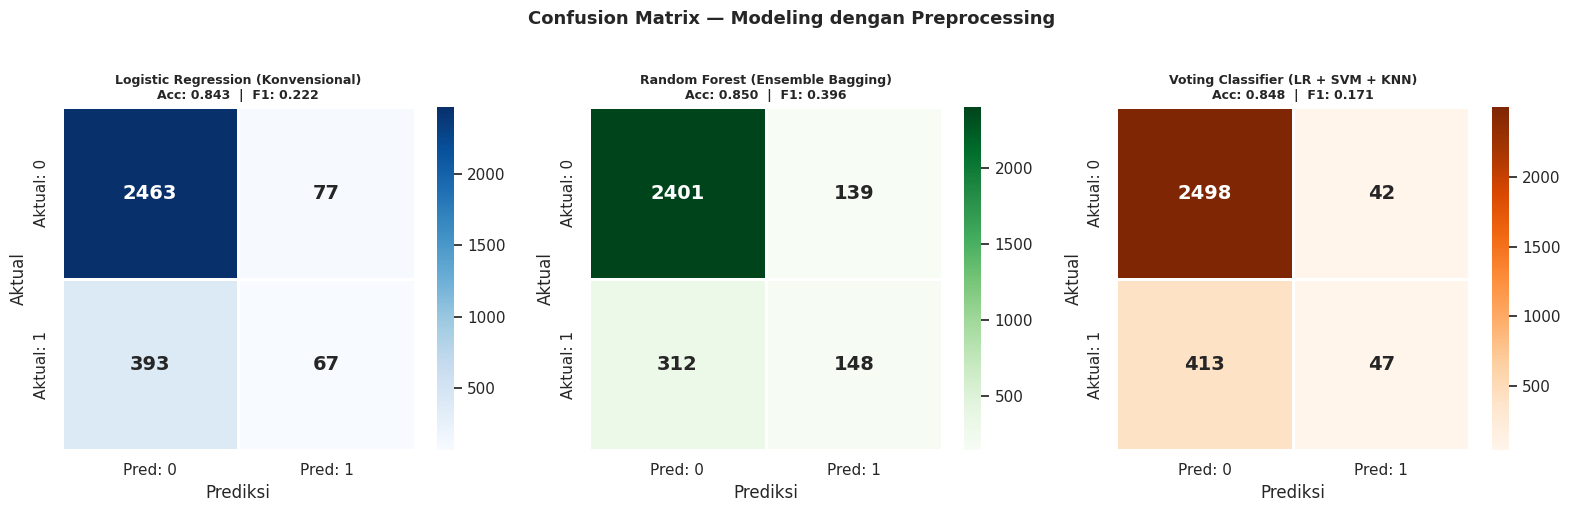

 Ringkasan Preprocessing:


,Accuracy,Precision,Recall,F1-Score
Model,,,,
Logistic Regression (Konvensional),0.8433,0.4653,0.1457,0.2219
Random Forest (Ensemble Bagging),0.8497,0.5157,0.3217,0.3963
Voting Classifier (LR + SVM + KNN),0.8483,0.5281,0.1022,0.1712


In [26]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, res, cmap_ in zip(axes, results_pp, ['Blues', 'Greens', 'Oranges']):
    sns.heatmap(res['CM'], annot=True, fmt='d', cmap=cmap_, ax=ax,
                xticklabels=['Pred: 0', 'Pred: 1'],
                yticklabels=['Aktual: 0', 'Aktual: 1'],
                linewidths=1, linecolor='white',
                annot_kws={'size': 14, 'weight': 'bold'})
    sn = res['Model'].replace('\n', ' ')
    ax.set_title(f"{sn}\nAcc: {res['Accuracy']:.3f}  |  F1: {res['F1-Score']:.3f}",
                 fontsize=9, fontweight='bold')
    ax.set_xlabel('Prediksi'); ax.set_ylabel('Aktual')

plt.suptitle('Confusion Matrix — Modeling dengan Preprocessing',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../plots/plot_cm_preprocessing.png', bbox_inches='tight')
plt.show()

summ_pp = pd.DataFrame([{k: r[k] for k in ['Model', 'Accuracy', 'Precision', 'Recall', 'F1-Score']}
                         for r in results_pp])
summ_pp['Model'] = summ_pp['Model'].str.replace('\n', ' ')
print(" Ringkasan Preprocessing:")
display(summ_pp.set_index('Model').style
        .format('{:.4f}')
        .background_gradient(cmap='YlGn', subset=['Accuracy', 'F1-Score']))


### 3.6 Perbandingan Direct vs Preprocessing

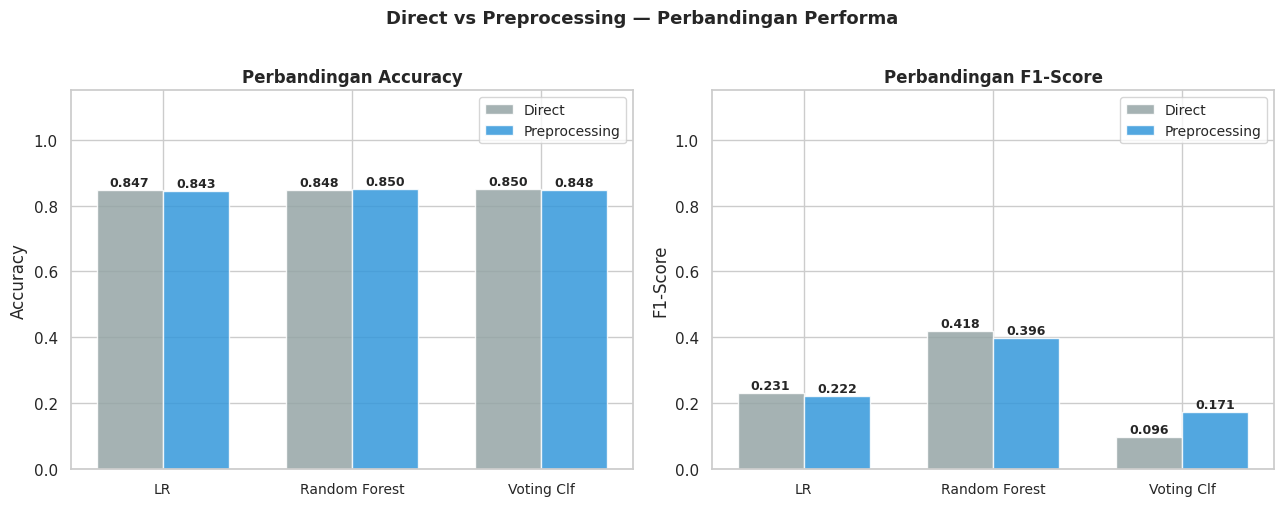

Disimpan: plots/plot_direct_vs_preprocessing.png


In [27]:
model_short = ['LR', 'Random Forest', 'Voting Clf']
fig, axes   = plt.subplots(1, 2, figsize=(13, 5))

for ax, metric in zip(axes, ['Accuracy', 'F1-Score']):
    x  = np.arange(len(model_short)); w = 0.35
    dv = [r[metric] for r in results_dir]
    pv = [r[metric] for r in results_pp]
    b1 = ax.bar(x - w/2, dv, w, label='Direct',        color='#95a5a6', alpha=0.85, edgecolor='white')
    b2 = ax.bar(x + w/2, pv, w, label='Preprocessing', color='#3498db', alpha=0.85, edgecolor='white')
    for b, v in [*zip(b1, dv), *zip(b2, pv)]:
        ax.text(b.get_x() + b.get_width()/2, b.get_height() + 0.003,
                f'{v:.3f}', ha='center', va='bottom', fontsize=9, fontweight='bold')
    ax.set_xticks(x); ax.set_xticklabels(model_short, fontsize=10)
    ax.set_title(f'Perbandingan {metric}', fontweight='bold', fontsize=12)
    ax.set_ylabel(metric); ax.set_ylim(0, 1.15); ax.legend(fontsize=10)

plt.suptitle('Direct vs Preprocessing — Perbandingan Performa',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('../plots/plot_direct_vs_preprocessing.png', bbox_inches='tight')
plt.show()
print("Disimpan: plots/plot_direct_vs_preprocessing.png")


---
##  Bagian 4 — Hyperparameter Tuning & Feature Selection
---


### 4.1 Feature Importance Analysis (Random Forest)

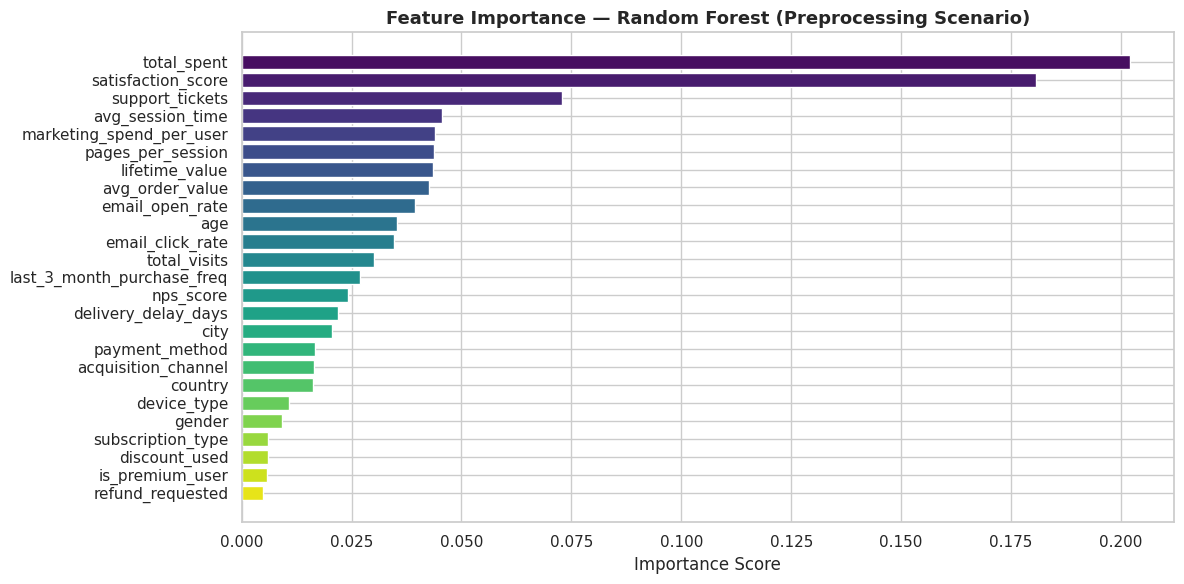

 Top-15 Fitur Terpilih (Feature Selection):
--------------------------------------------------
   1. total_spent                              0.2019
   2. satisfaction_score                       0.1807
   3. support_tickets                          0.0729
   4. avg_session_time                         0.0455
   5. marketing_spend_per_user                 0.0440
   6. pages_per_session                        0.0437
   7. lifetime_value                           0.0436
   8. avg_order_value                          0.0427
   9. email_open_rate                          0.0393
  10. age                                      0.0354
  11. email_click_rate                         0.0346
  12. total_visits                             0.0302
  13. last_3_month_purchase_freq               0.0269
  14. nps_score                                0.0241
  15. delivery_delay_days                      0.0219


In [28]:
# Gunakan RF dari skenario preprocessing
rf_for_fi   = results_pp[1]['obj']
importances = pd.Series(rf_for_fi.feature_importances_, index=X_pp.columns)
importances = importances.sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(12, 6))
palette_fi = sns.color_palette('viridis', len(importances))
ax.barh(importances.index, importances.values, color=palette_fi, edgecolor='white')
ax.set_title('Feature Importance — Random Forest (Preprocessing Scenario)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Importance Score')
ax.invert_yaxis()
plt.tight_layout()
plt.savefig('../plots/plot_feature_importance.png', bbox_inches='tight')
plt.show()

TOP_N        = 15
top_features = importances.head(TOP_N).index.tolist()
print(f" Top-{TOP_N} Fitur Terpilih (Feature Selection):")
print("-" * 50)
for i, f in enumerate(top_features, 1):
    print(f"  {i:2d}. {f:<40s} {importances[f]:.4f}")


### 4.2 Subset Data & Re-Scaling

In [29]:
# Subset ke top features, scale ulang (scaler baru khusus top features)
scaler_fs = StandardScaler()
X_tr_fs   = scaler_fs.fit_transform(X_tr_p[top_features])   # fit + transform
X_te_fs   = scaler_fs.transform(X_te_p[top_features])       # transform saja

print(f"Shape data latih (feature selected) : {X_tr_fs.shape}")
print(f"Shape data uji   (feature selected) : {X_te_fs.shape}")
print(f"\nFitur berkurang: {X_pp.shape[1]} → {len(top_features)} kolom")


Shape data latih (feature selected) : (12000, 15)
Shape data uji   (feature selected) : (3000, 15)

Fitur berkurang: 25 → 15 kolom


### 4.3 Hyperparameter Tuning — Logistic Regression (GridSearchCV)

In [30]:
param_lr = {
    'C'      : [0.001, 0.01, 0.1, 1, 10, 100],
    'solver' : ['lbfgs', 'liblinear'],
    'penalty': ['l2']
}

gs_lr = GridSearchCV(
    LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    param_lr, cv=5, scoring='f1', n_jobs=-1, verbose=0)

gs_lr.fit(X_tr_fs, y_tr_p)

print(f" LR Best Parameters : {gs_lr.best_params_}")
print(f"   CV F1-Score (mean)  : {gs_lr.best_score_:.4f}")


 LR Best Parameters : {'C': 10, 'penalty': 'l2', 'solver': 'lbfgs'}
   CV F1-Score (mean)  : 0.2567


### 4.4 Hyperparameter Tuning — Random Forest (RandomizedSearchCV)

In [31]:
param_rf = {
    'n_estimators'     : [100, 200, 300, 500],
    'max_depth'        : [None, 5, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf' : [1, 2, 4],
    'max_features'     : ['sqrt', 'log2'],
    'bootstrap'        : [True, False]
}

rs_rf = RandomizedSearchCV(
    RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1),
    param_rf, n_iter=20, cv=5, scoring='f1',
    random_state=RANDOM_STATE, n_jobs=-1, verbose=0)

rs_rf.fit(X_tr_fs, y_tr_p)

print(f" RF Best Parameters  : {rs_rf.best_params_}")
print(f"   CV F1-Score (mean)  : {rs_rf.best_score_:.4f}")


 RF Best Parameters  : {'n_estimators': 500, 'min_samples_split': 2, 'min_samples_leaf': 2, 'max_features': 'log2', 'max_depth': 20, 'bootstrap': False}
   CV F1-Score (mean)  : 0.4484


### 4.5 Hyperparameter Tuning — Voting Classifier (GridSearchCV)

In [32]:
base_vc = VotingClassifier(
    estimators=[
        ('lr',  LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)),
        ('svm', SVC(probability=True, random_state=RANDOM_STATE)),
        ('knn', KNeighborsClassifier())
    ], voting='soft')

param_vc = {
    'lr__C'           : [0.01, 0.1, 1, 10],
    'knn__n_neighbors': [3, 5, 7, 9],
    'svm__C'          : [0.1, 1, 10]
}

gs_vc = GridSearchCV(base_vc, param_vc, cv=5, scoring='f1', n_jobs=-1, verbose=0)
gs_vc.fit(X_tr_fs, y_tr_p)

print(f" VC Best Parameters  : {gs_vc.best_params_}")
print(f"   CV F1-Score (mean)  : {gs_vc.best_score_:.4f}")


 VC Best Parameters  : {'knn__n_neighbors': 3, 'lr__C': 10, 'svm__C': 0.1}
   CV F1-Score (mean)  : 0.2321


### 4.6 Evaluasi Model Tuned

In [33]:
tuned_models = {
    'Logistic Regression\n(Tuned)': gs_lr.best_estimator_,
    'Random Forest\n(Tuned)'      : rs_rf.best_estimator_,
    'Voting Classifier\n(Tuned)'  : gs_vc.best_estimator_
}

print(" Evaluasi best estimator pada data uji...")
results_tuned = []
for name, mdl in tuned_models.items():
    res = eval_model(name, mdl, X_tr_fs, X_te_fs, y_tr_p, y_te_p)
    results_tuned.append(res)


 Evaluasi best estimator pada data uji...

  Logistic Regression (Tuned)
  Accuracy  : 0.8423  (84.23%)
  Precision : 0.4552
  Recall    : 0.1435
  F1-Score  : 0.2182

  Classification Report:
                 precision    recall  f1-score   support

Tidak Churn (0)       0.86      0.97      0.91      2540
      Churn (1)       0.46      0.14      0.22       460

       accuracy                           0.84      3000
      macro avg       0.66      0.56      0.57      3000
   weighted avg       0.80      0.84      0.81      3000


  Random Forest (Tuned)
  Accuracy  : 0.8527  (85.27%)
  Precision : 0.5256
  Recall    : 0.4022
  F1-Score  : 0.4557

  Classification Report:
                 precision    recall  f1-score   support

Tidak Churn (0)       0.90      0.93      0.91      2540
      Churn (1)       0.53      0.40      0.46       460

       accuracy                           0.85      3000
      macro avg       0.71      0.67      0.69      3000
   weighted avg       0.84    

### 4.7 Confusion Matrix Tuned

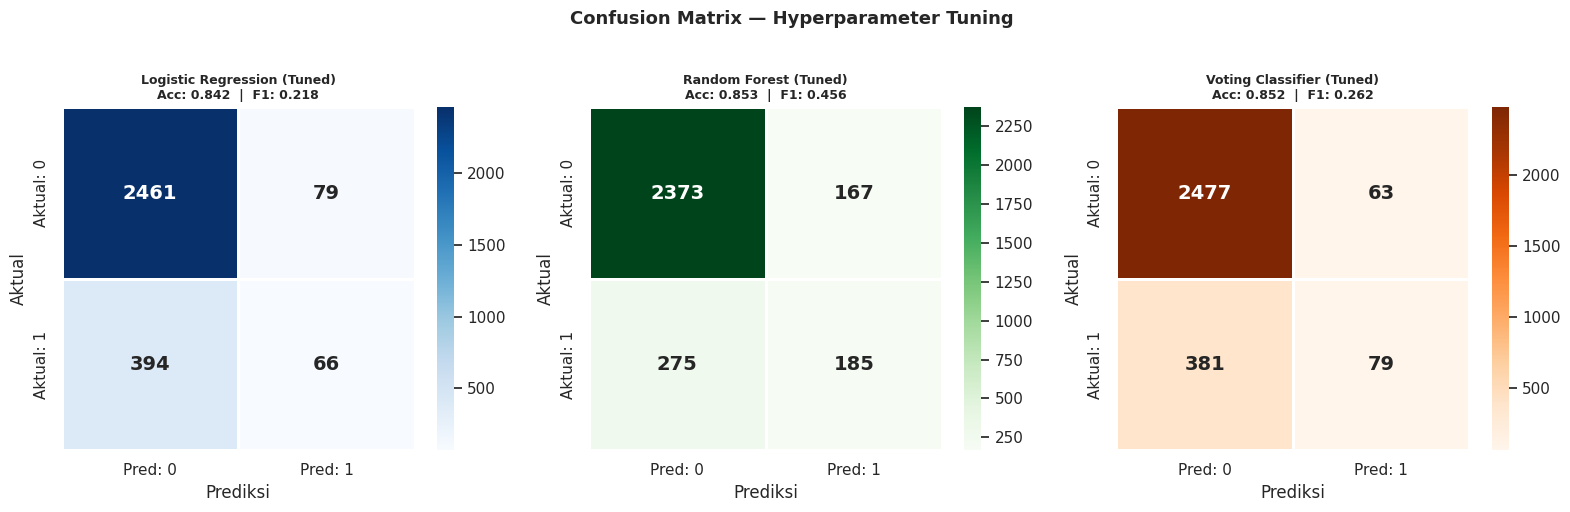

 Disimpan: plots/plot_cm_tuned.png


In [34]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, res, cmap_ in zip(axes, results_tuned, ['Blues', 'Greens', 'Oranges']):
    sns.heatmap(res['CM'], annot=True, fmt='d', cmap=cmap_, ax=ax,
                xticklabels=['Pred: 0', 'Pred: 1'],
                yticklabels=['Aktual: 0', 'Aktual: 1'],
                linewidths=1, linecolor='white',
                annot_kws={'size': 14, 'weight': 'bold'})
    sn = res['Model'].replace('\n', ' ')
    ax.set_title(f"{sn}\nAcc: {res['Accuracy']:.3f}  |  F1: {res['F1-Score']:.3f}",
                 fontsize=9, fontweight='bold')
    ax.set_xlabel('Prediksi'); ax.set_ylabel('Aktual')

plt.suptitle('Confusion Matrix — Hyperparameter Tuning',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../plots/plot_cm_tuned.png', bbox_inches='tight')
plt.show()
print(" Disimpan: plots/plot_cm_tuned.png")


### 4.8 Perbandingan Lengkap Semua 9 Model (3 Model × 3 Skenario)

In [35]:
all_rows = []
scenarios_dict = {
    'Direct'        : results_dir,
    'Preprocessing' : results_pp,
    'Tuned'         : results_tuned
}
for sc, rlist in scenarios_dict.items():
    for r in rlist:
        all_rows.append({
            'Skenario' : sc,
            'Model'    : r['Model'].replace('\n', ' '),
            'Accuracy' : r['Accuracy'],
            'Precision': r['Precision'],
            'Recall'   : r['Recall'],
            'F1-Score' : r['F1-Score']
        })
df_all = pd.DataFrame(all_rows)

print(" Tabel Perbandingan Lengkap (9 Model):")
display(df_all.style
        .format({k: '{:.4f}' for k in ['Accuracy','Precision','Recall','F1-Score']})
        .background_gradient(cmap='YlGn', subset=['Accuracy','F1-Score'])
        .set_caption('Evaluasi 9 Model — 3 Skenario'))


 Tabel Perbandingan Lengkap (9 Model):


,Skenario,Model,Accuracy,Precision,Recall,F1-Score
0,Direct,Logistic Regression (Konvensional),0.8467,0.5000,0.1500,0.2308
1,Direct,Random Forest (Ensemble Bagging),0.8477,0.5046,0.3565,0.4178
2,Direct,Voting Classifier (LR + SVM + KNN),0.8497,0.6154,0.0522,0.0962
3,Preprocessing,Logistic Regression (Konvensional),0.8433,0.4653,0.1457,0.2219
4,Preprocessing,Random Forest (Ensemble Bagging),0.8497,0.5157,0.3217,0.3963
5,Preprocessing,Voting Classifier (LR + SVM + KNN),0.8483,0.5281,0.1022,0.1712
6,Tuned,Logistic Regression (Tuned),0.8423,0.4552,0.1435,0.2182
7,Tuned,Random Forest (Tuned),0.8527,0.5256,0.4022,0.4557
8,Tuned,Voting Classifier (Tuned),0.8520,0.5563,0.1717,0.2625


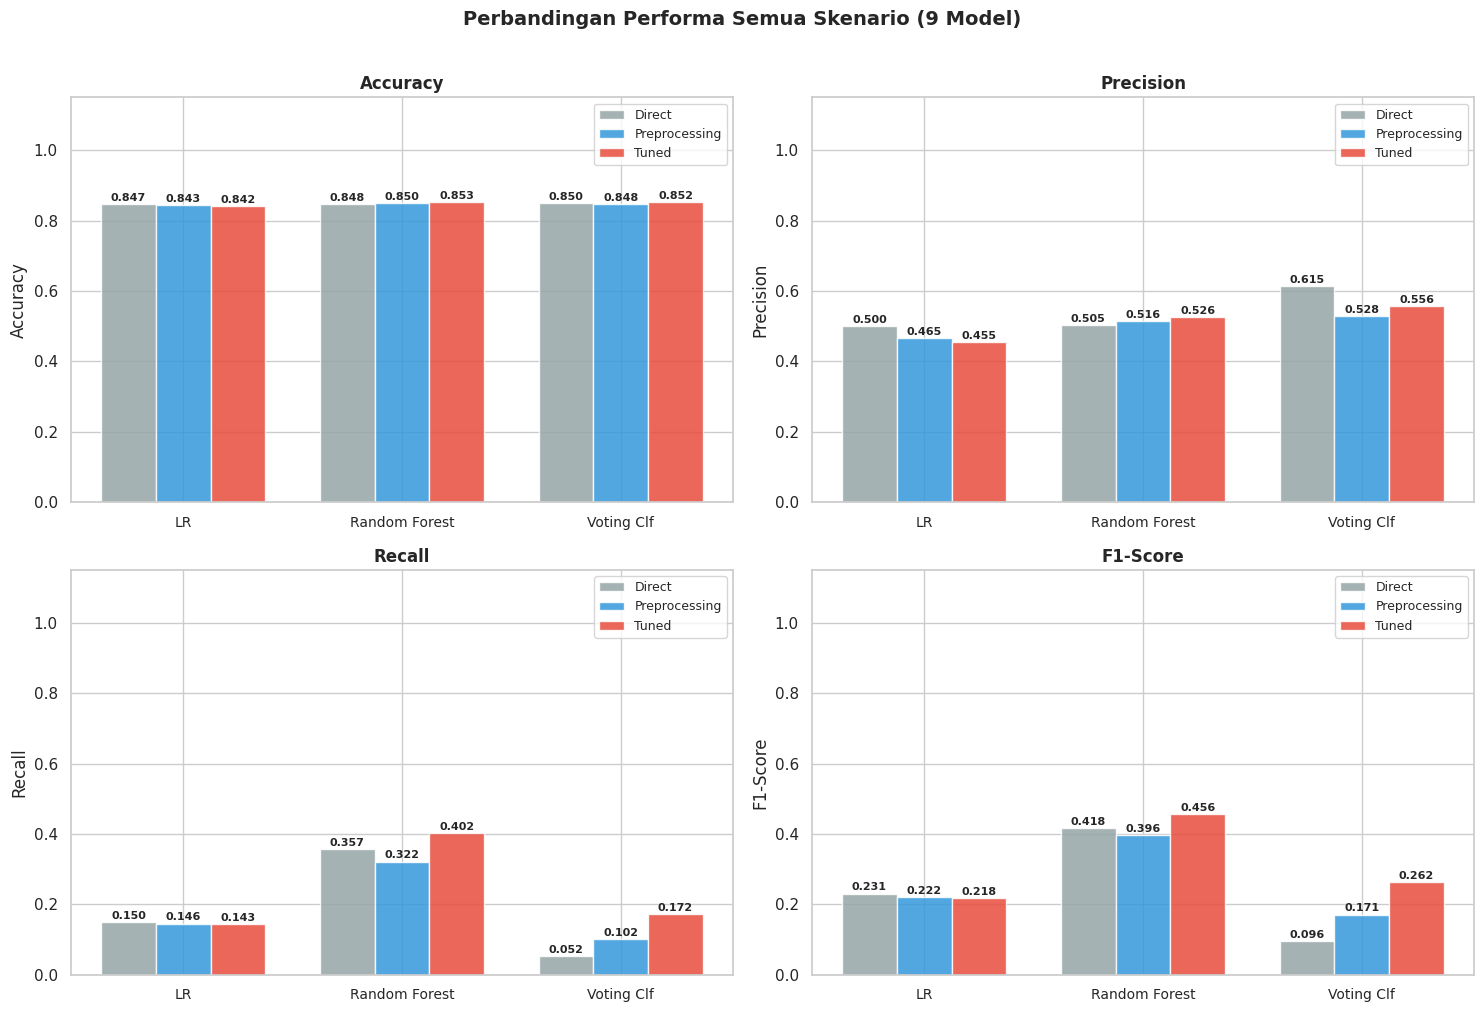

 Disimpan: plots/plot_semua_skenario.png


In [36]:
# ── Grafik perbandingan semua skenario ──────────────────────────────────────
model_short3 = ['LR', 'Random Forest', 'Voting Clf']
sc_colors    = {'Direct': '#95a5a6', 'Preprocessing': '#3498db', 'Tuned': '#e74c3c'}

fig, axes = plt.subplots(2, 2, figsize=(15, 10))

for ax, metric in zip(axes.flatten(), ['Accuracy', 'Precision', 'Recall', 'F1-Score']):
    x = np.arange(len(model_short3)); w = 0.25
    for i, (sc, rlist) in enumerate(scenarios_dict.items()):
        vals = [r[metric] for r in rlist]
        bars = ax.bar(x + i*w, vals, w, label=sc,
                      color=sc_colors[sc], alpha=0.85, edgecolor='white')
        for b, v in zip(bars, vals):
            ax.text(b.get_x() + b.get_width()/2, b.get_height() + 0.003,
                    f'{v:.3f}', ha='center', va='bottom', fontsize=8, fontweight='bold')
    ax.set_xticks(x + w)
    ax.set_xticklabels(model_short3, fontsize=10)
    ax.set_title(metric, fontweight='bold', fontsize=12)
    ax.set_ylabel(metric); ax.set_ylim(0, 1.15); ax.legend(fontsize=9)

plt.suptitle('Perbandingan Performa Semua Skenario (9 Model)',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('../plots/plot_semua_skenario.png', bbox_inches='tight')
plt.show()
print(" Disimpan: plots/plot_semua_skenario.png")


### 4.9 Identifikasi Model Terbaik

In [37]:
best_row = df_all.loc[df_all['F1-Score'].idxmax()]

print("=" * 55)
print("  MODEL TERBAIK (F1-Score Tertinggi)")
print("=" * 55)
print(f"  Skenario  : {best_row['Skenario']}")
print(f"  Model     : {best_row['Model']}")
print(f"  Accuracy  : {best_row['Accuracy']:.4f}")
print(f"  Precision : {best_row['Precision']:.4f}")
print(f"  Recall    : {best_row['Recall']:.4f}")
print(f"  F1-Score  : {best_row['F1-Score']:.4f}")
print("=" * 55)


  MODEL TERBAIK (F1-Score Tertinggi)
  Skenario  : Tuned
  Model     : Random Forest (Tuned)
  Accuracy  : 0.8527
  Precision : 0.5256
  Recall    : 0.4022
  F1-Score  : 0.4557


---
##  Bagian 5 — Simpan Model untuk Deployment Streamlit
---


In [39]:
# Model terbaik = Random Forest (Tuned) — index 1 di results_tuned
best_model = results_tuned[1]['obj']
yp_best    = best_model.predict(X_te_fs)

model_artifacts = {
    'model'          : best_model,
    'scaler'         : scaler_fs,
    'features'       : top_features,
    'le_map'         : le_map,
    'model_name'     : 'Random Forest (Tuned)',
    'f1_score'       : round(f1_score(y_te_p, yp_best, zero_division=0), 4),
    'accuracy'       : round(accuracy_score(y_te_p, yp_best), 4),
    'best_lr_params' : gs_lr.best_params_,
    'best_rf_params' : rs_rf.best_params_,
    'best_vc_params' : gs_vc.best_params_,
}

joblib.dump(model_artifacts, '../model/churn_model.pkl')

print(" Model berhasil disimpan ke '../model/churn_model.pkl'")
print(f"   File size  : {os.path.getsize('../model/churn_model.pkl') / 1024:.0f} KB")
print(f"   Model      : {model_artifacts['model_name']}")
print(f"   Fitur      : {len(top_features)} fitur")
print(f"   F1-Score   : {model_artifacts['f1_score']}")
print(f"   Accuracy   : {model_artifacts['accuracy']}")


 Model berhasil disimpan ke '../model/churn_model.pkl'
   File size  : 69823 KB
   Model      : Random Forest (Tuned)
   Fitur      : 15 fitur
   F1-Score   : 0.4557
   Accuracy   : 0.8527
